# # House Prices  
**Author:** Valérie RUSSO  

**Kaggle Competition:** House Prices - Advanced Regression Techniques  

*This notebook presents an end-to-end machine learning project aiming to predict house prices using advanced regression techniques.*

## Approach
- Data preprocessing (handling missing values, encoding, scaling)  
- Advanced feature engineering (manual encoding of ordinal variables, creation of new features)  
- Cross-validation with Out-of-Fold (OOF) predictions  
- Hyperparameter tuning (RandomizedSearchCV)  
- Model comparison (Ridge, Random Forest, LightGBM, XGBoost, CatBoost)  
- Model ensembling (blending of the top 3 models)  
- Stacking with meta-models (evaluated but less effective than blending)  

## Result
Final score: **0.12422 RMSE (log-transformed target)**


# 1. Data Loading

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



In [2]:
from sklearn import set_config
set_config(transform_output="pandas")

In [ ]:
train_val = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv")
train_val.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
X_test = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv")
X_test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
modele = pd.read_csv("/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv")
modele.head(5)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [6]:
X_train_val=train_val.drop("SalePrice", axis=1)

In [7]:
# Transformation of the Id column into index
X_train_val.set_index("Id", inplace=True)
X_test.set_index("Id", inplace=True)

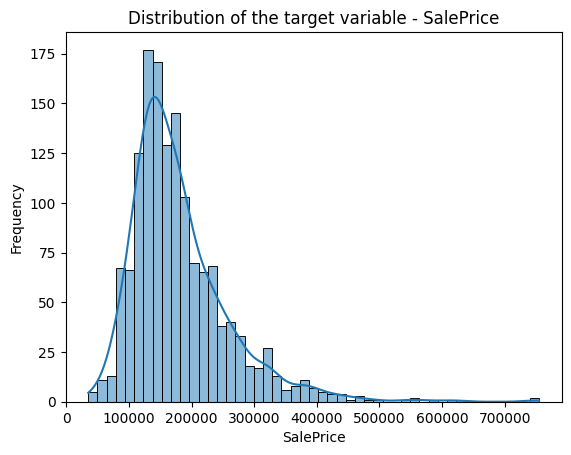

In [8]:
y_train_val = train_val.set_index("Id")["SalePrice"]
y_train_val.mean()

# Distribution of the target variable
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(y_train_val, kde=True)
plt.title("Distribution of the target variable - SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.show()

In [9]:
X_train_val.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   Alley          91 non-null     str    
 6   LotShape       1460 non-null   str    
 7   LandContour    1460 non-null   str    
 8   Utilities      1460 non-null   str    
 9   LotConfig      1460 non-null   str    
 10  LandSlope      1460 non-null   str    
 11  Neighborhood   1460 non-null   str    
 12  Condition1     1460 non-null   str    
 13  Condition2     1460 non-null   str    
 14  BldgType       1460 non-null   str    
 15  HouseStyle     1460 non-null   str    
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt      1460

# 2. Data cleaning and Feature engineering

In [10]:
# MSSubClass: The building class is a categorical variable, not numeric from data description. It needs to be converted to a categorical variable.
# Same for OverallQual and OverallCond, which are ratings from 1 to 10,
# but they represent categories of quality and condition, not continuous numeric values.
X_train_val["MSSubClass cat"] = X_train_val["MSSubClass"].astype(str)
X_test["MSSubClass cat"] = X_test["MSSubClass"].astype(str)

# Put those wrong numerical features in a list, and remove them from the list of numerical features
wrong_numerical_features = ["MSSubClass"]

In [11]:
X_train_val.drop(columns=wrong_numerical_features, inplace=True)
X_test.drop(columns=wrong_numerical_features, inplace=True)

In [12]:
# Checking the percentage of missing values for numerical features
missing_values = X_train_val.isnull().sum()
missing_percentage = (missing_values / len(X_train_val)) * 100
print("Percentage of missing values by column:")
print(missing_percentage[missing_percentage > 0])

Percentage of missing values by column:
LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64


In [13]:
ordinal_features = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC",
                    "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC",
                    "BsmtFinType1","BsmtFinType2", "Functional", "GarageFinish",
                    "PavedDrive", "LandSlope", "BsmtExposure", "OverallQual", "OverallCond"]

In [14]:
# Checking the percentage of missing values for ordinal features
for col in ordinal_features:
    X_train_val[col] = X_train_val[col].fillna("NA")
    X_test[col] = X_test[col].fillna("NA")

In [15]:
# Affiche toutes les colonnes numériques de X_train_val
numerical_features=X_train_val.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features

['LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

In [16]:
# Looking into data description, transformation of ordinal data into numerical data is needed when there is an order in the categories.
# For example, for the feature "ExterQual" (Exterior material quality), the categories are "Ex", "Gd", "TA", "Fa", and "Po", which represent different levels of quality. We can map these categories to numerical values based on their order of quality, such as Ex=5, Gd=4, TA=3, Fa=2, Po=1. 
# This way, we can capture the ordinal relationship between the categories and use it in our model.
# Manual mapping for ordinal features is necessary to preserve the order of categories and ensure that the model can learn from the ordinal relationships in the data.
# Ordinal data will be int data type
quality_mapping = {"Ex": 5, "Gd": 4, "TA": 3, "Fa": 2, "Po": 1, "NA": 0}
X_train_val["ExterQual num"] = X_train_val["ExterQual"].map(quality_mapping)
X_test["ExterQual num"] = X_test["ExterQual"].map(quality_mapping)
X_train_val["ExterCond num"] = X_train_val["ExterCond"].map(quality_mapping)
X_test["ExterCond num"] = X_test["ExterCond"].map(quality_mapping)
X_train_val["BsmtQual num"] = X_train_val["BsmtQual"].map(quality_mapping)
X_test["BsmtQual num"] = X_test["BsmtQual"].map(quality_mapping)
X_train_val["BsmtCond num"] = X_train_val["BsmtCond"].map(quality_mapping)
X_test["BsmtCond num"] = X_test["BsmtCond"].map(quality_mapping)
X_train_val["HeatingQC num"] = X_train_val["HeatingQC"].map(quality_mapping)
X_test["HeatingQC num"] = X_test["HeatingQC"].map(quality_mapping)
X_train_val["KitchenQual num"] = X_train_val["KitchenQual"].map(quality_mapping)
X_test["KitchenQual num"] = X_test["KitchenQual"].map(quality_mapping)
X_train_val["FireplaceQu num"] = X_train_val["FireplaceQu"].map(quality_mapping)
X_test["FireplaceQu num"] = X_test["FireplaceQu"].map(quality_mapping)
X_train_val["GarageQual num"] = X_train_val["GarageQual"].map(quality_mapping)
X_test["GarageQual num"] = X_test["GarageQual"].map(quality_mapping)
X_train_val["GarageCond num"] = X_train_val["GarageCond"].map(quality_mapping)
X_test["GarageCond num"] = X_test["GarageCond"].map(quality_mapping)
X_train_val["PoolQC num"] = X_train_val["PoolQC"].map(quality_mapping)
X_test["PoolQC num"] = X_test["PoolQC"].map(quality_mapping)
# Other mapping for features with different categories
exposure_mapping = {"Gd": 4, "Av": 3, "Mn": 2, "No": 1, "NA": 0}
X_train_val["BsmtExposure num"] = X_train_val["BsmtExposure"].map(exposure_mapping)
X_test["BsmtExposure num"] = X_test["BsmtExposure"].map(exposure_mapping)
# Other mapping for features with different categories
bsmtf_mapping = {"GLQ": 6, "ALQ": 5, "BLQ": 4, "Rec": 3, "LwQ": 2, "Unf": 1, "NA": 0}
X_train_val["BsmtFinType1 num"] = X_train_val["BsmtFinType1"].map(bsmtf_mapping)
X_test["BsmtFinType1 num"] = X_test["BsmtFinType1"].map(bsmtf_mapping)
X_train_val["BsmtFinType2 num"] = X_train_val["BsmtFinType2"].map(bsmtf_mapping)
X_test["BsmtFinType2 num"] = X_test["BsmtFinType2"].map(bsmtf_mapping)
# Other mapping for Functional feature
functional_mapping = {"Typ": 7, "Min1": 6, "Min2": 5, "Mod": 4, "Maj1": 3, "Maj2": 2, "Sev": 1, "Sal": 0}
X_train_val["Functional num"] = X_train_val["Functional"].map(functional_mapping)
X_test["Functional num"] = X_test["Functional"].map(functional_mapping)
# Other mapping for GarageFinish feature
garagefinish_mapping = {"Fin": 3, "RFn": 2, "Unf": 1, "NA": 0}
X_train_val["GarageFinish num"] = X_train_val["GarageFinish"].map(garagefinish_mapping)
X_test["GarageFinish num"] = X_test["GarageFinish"].map(garagefinish_mapping)
# Other mapping for PavedDrive feature
paveddrive_mapping = {"Y": 3, "P": 2, "N": 1}
X_train_val["PavedDrive num"] = X_train_val["PavedDrive"].map(paveddrive_mapping)
X_test["PavedDrive num"] = X_test["PavedDrive"].map(paveddrive_mapping)
# Other mapping for LandSlope feature
landslope_mapping = {"Gtl": 3, "Mod": 2, "Sev": 1}
X_train_val["LandSlope num"] = X_train_val["LandSlope"].map(landslope_mapping)
X_test["LandSlope num"] = X_test["LandSlope"].map(landslope_mapping)
#mapping for OverallQual and OverallCond features
overall_mapping = {10: 10, 9: 9, 8: 8, 7: 7, 6: 6, 5: 5, 4: 4, 3: 3, 2: 2, 1: 1, 0: 0}
X_train_val["OverallQual num"] = X_train_val["OverallQual"].map(overall_mapping)
X_test["OverallQual num"] = X_test["OverallQual"].map(overall_mapping)
X_train_val["OverallCond num"] = X_train_val["OverallCond"].map(overall_mapping)
X_test["OverallCond num"] = X_test["OverallCond"].map(overall_mapping)


In [17]:
# deletion of the original ordinal features after transformation
X_train_val.drop(columns=ordinal_features, inplace=True)
X_test.drop(columns=ordinal_features, inplace=True)

#update of the list of numerical features after transformation
numerical_features = X_train_val.select_dtypes(include=["int64", "float64"]).columns.tolist()
#update of the list of categorical features after transformation
categorical_features = X_train_val.select_dtypes(include=["object", "string"]).columns.tolist()
#update of ordinal features list after transformation
ordinal_features = [feature + " num" for feature in ordinal_features]
ordinal_features

['ExterQual num',
 'ExterCond num',
 'BsmtQual num',
 'BsmtCond num',
 'HeatingQC num',
 'KitchenQual num',
 'FireplaceQu num',
 'GarageQual num',
 'GarageCond num',
 'PoolQC num',
 'BsmtFinType1 num',
 'BsmtFinType2 num',
 'Functional num',
 'GarageFinish num',
 'PavedDrive num',
 'LandSlope num',
 'BsmtExposure num',
 'OverallQual num',
 'OverallCond num']

In [18]:
X_train_val.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 1 to 1460
Data columns (total 79 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MSZoning          1460 non-null   str    
 1   LotFrontage       1201 non-null   float64
 2   LotArea           1460 non-null   int64  
 3   Street            1460 non-null   str    
 4   Alley             91 non-null     str    
 5   LotShape          1460 non-null   str    
 6   LandContour       1460 non-null   str    
 7   Utilities         1460 non-null   str    
 8   LotConfig         1460 non-null   str    
 9   Neighborhood      1460 non-null   str    
 10  Condition1        1460 non-null   str    
 11  Condition2        1460 non-null   str    
 12  BldgType          1460 non-null   str    
 13  HouseStyle        1460 non-null   str    
 14  YearBuilt         1460 non-null   int64  
 15  YearRemodAdd      1460 non-null   int64  
 16  RoofStyle         1460 non-null   str    
 17  RoofMa

In [19]:
#number of different values for each  feature
for col in X_train_val.columns:
    num_unique = X_train_val[col].nunique()
    if num_unique <=1:
        print(f"{col}: {num_unique} unique values")
    else:
        print(f"More than 1 value: {col}: {num_unique} unique values, {X_train_val[col].dtype}")

More than 1 value: MSZoning: 5 unique values, str
More than 1 value: LotFrontage: 110 unique values, float64
More than 1 value: LotArea: 1073 unique values, int64
More than 1 value: Street: 2 unique values, str
More than 1 value: Alley: 2 unique values, str
More than 1 value: LotShape: 4 unique values, str
More than 1 value: LandContour: 4 unique values, str
More than 1 value: Utilities: 2 unique values, str
More than 1 value: LotConfig: 5 unique values, str
More than 1 value: Neighborhood: 25 unique values, str
More than 1 value: Condition1: 9 unique values, str
More than 1 value: Condition2: 8 unique values, str
More than 1 value: BldgType: 5 unique values, str
More than 1 value: HouseStyle: 8 unique values, str
More than 1 value: YearBuilt: 112 unique values, int64
More than 1 value: YearRemodAdd: 61 unique values, int64
More than 1 value: RoofStyle: 6 unique values, str
More than 1 value: RoofMatl: 8 unique values, str
More than 1 value: Exterior1st: 15 unique values, str
More than

In [20]:
# autotmatic test to check in categorical features if there are low variance features (one category is dominant) 
# or high missing features (most values are missing)
threshold_unique = 0.99
threshold_missing = 0.8
low_variance_cat_cols = []
high_missing_cols = []
for col in X_train_val.select_dtypes(include=["object", "string"]).columns:
    top_freq = X_train_val[col].value_counts(normalize=True).iloc[0]
    if top_freq > threshold_unique:
        low_variance_cat_cols.append(col)
    if X_train_val[col].isnull().mean() > threshold_missing:
        high_missing_cols.append(col)
print("Low variance categorical columns:", low_variance_cat_cols)
print("High missing categorical columns:", high_missing_cols)


Low variance categorical columns: ['Street', 'Utilities']
High missing categorical columns: ['Alley', 'Fence', 'MiscFeature']


In [21]:
# deletion of the Low variance categorical columns and high missing categorical columns
X_train_val.drop(columns=low_variance_cat_cols + high_missing_cols, inplace=True)
X_test.drop(columns=low_variance_cat_cols + high_missing_cols, inplace=True)

In [22]:
#categorical features without ordinal features :
categorical_features = X_train_val.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_features

['MSZoning',
 'LotShape',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'Foundation',
 'Heating',
 'CentralAir',
 'Electrical',
 'GarageType',
 'SaleType',
 'SaleCondition',
 'MSSubClass cat']

In [23]:
# Correlation values for numerical features and ordinal features with the target variable
cols_to_include = list(numerical_features) + ["SalePrice"]
cols_to_include


['LotFrontage',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'ExterQual num',
 'ExterCond num',
 'BsmtQual num',
 'BsmtCond num',
 'HeatingQC num',
 'KitchenQual num',
 'FireplaceQu num',
 'GarageQual num',
 'GarageCond num',
 'PoolQC num',
 'BsmtExposure num',
 'BsmtFinType1 num',
 'BsmtFinType2 num',
 'Functional num',
 'GarageFinish num',
 'PavedDrive num',
 'LandSlope num',
 'OverallQual num',
 'OverallCond num',
 'SalePrice']

In [24]:
df_corr = (
    X_train_val
    .assign(SalePrice=y_train_val.values)[cols_to_include]
)
corr = df_corr.corr()["SalePrice"].sort_values(ascending=False)

print(corr.head(35))

SalePrice           1.000000
OverallQual num     0.790982
GrLivArea           0.708624
ExterQual num       0.682639
KitchenQual num     0.659600
GarageCars          0.640409
GarageArea          0.623431
TotalBsmtSF         0.613581
1stFlrSF            0.605852
BsmtQual num        0.585207
FullBath            0.560664
GarageFinish num    0.549247
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
FireplaceQu num     0.520438
YearRemodAdd        0.507101
GarageYrBlt         0.486362
MasVnrArea          0.477493
Fireplaces          0.466929
HeatingQC num       0.427649
BsmtFinSF1          0.386420
BsmtExposure num    0.374696
LotFrontage         0.351799
WoodDeckSF          0.324413
2ndFlrSF            0.319334
OpenPorchSF         0.315856
BsmtFinType1 num    0.304908
HalfBath            0.284108
GarageQual num      0.273839
LotArea             0.263843
GarageCond num      0.263191
PavedDrive num      0.231357
BsmtFullBath        0.227122
BsmtUnfSF           0.214479
BsmtCond num  

In [25]:
numerical_top_features = corr[abs(corr)>0.2].index.drop("SalePrice")
numerical_top_features

Index(['OverallQual num', 'GrLivArea', 'ExterQual num', 'KitchenQual num',
       'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'BsmtQual num',
       'FullBath', 'GarageFinish num', 'TotRmsAbvGrd', 'YearBuilt',
       'FireplaceQu num', 'YearRemodAdd', 'GarageYrBlt', 'MasVnrArea',
       'Fireplaces', 'HeatingQC num', 'BsmtFinSF1', 'BsmtExposure num',
       'LotFrontage', 'WoodDeckSF', '2ndFlrSF', 'OpenPorchSF',
       'BsmtFinType1 num', 'HalfBath', 'GarageQual num', 'LotArea',
       'GarageCond num', 'PavedDrive num', 'BsmtFullBath', 'BsmtUnfSF',
       'BsmtCond num'],
      dtype='str')

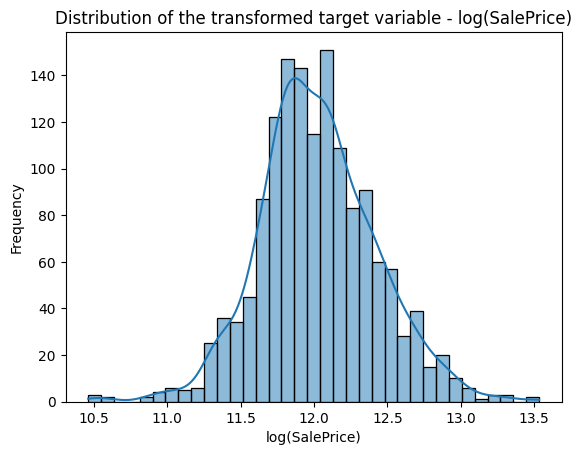

In [26]:
# Transformation of the target variable with log to reduce the effect of extreme values
y_train_val_log = np.log1p(y_train_val)

# Distribution of the transformed target variable
sns.histplot(y_train_val_log, kde=True)
plt.title("Distribution of the transformed target variable - log(SalePrice)")
plt.xlabel("log(SalePrice)")
plt.ylabel("Frequency")
plt.show()

In [27]:
continuous_numerical_features = [col for col in numerical_top_features if X_train_val[col].nunique() > 20]

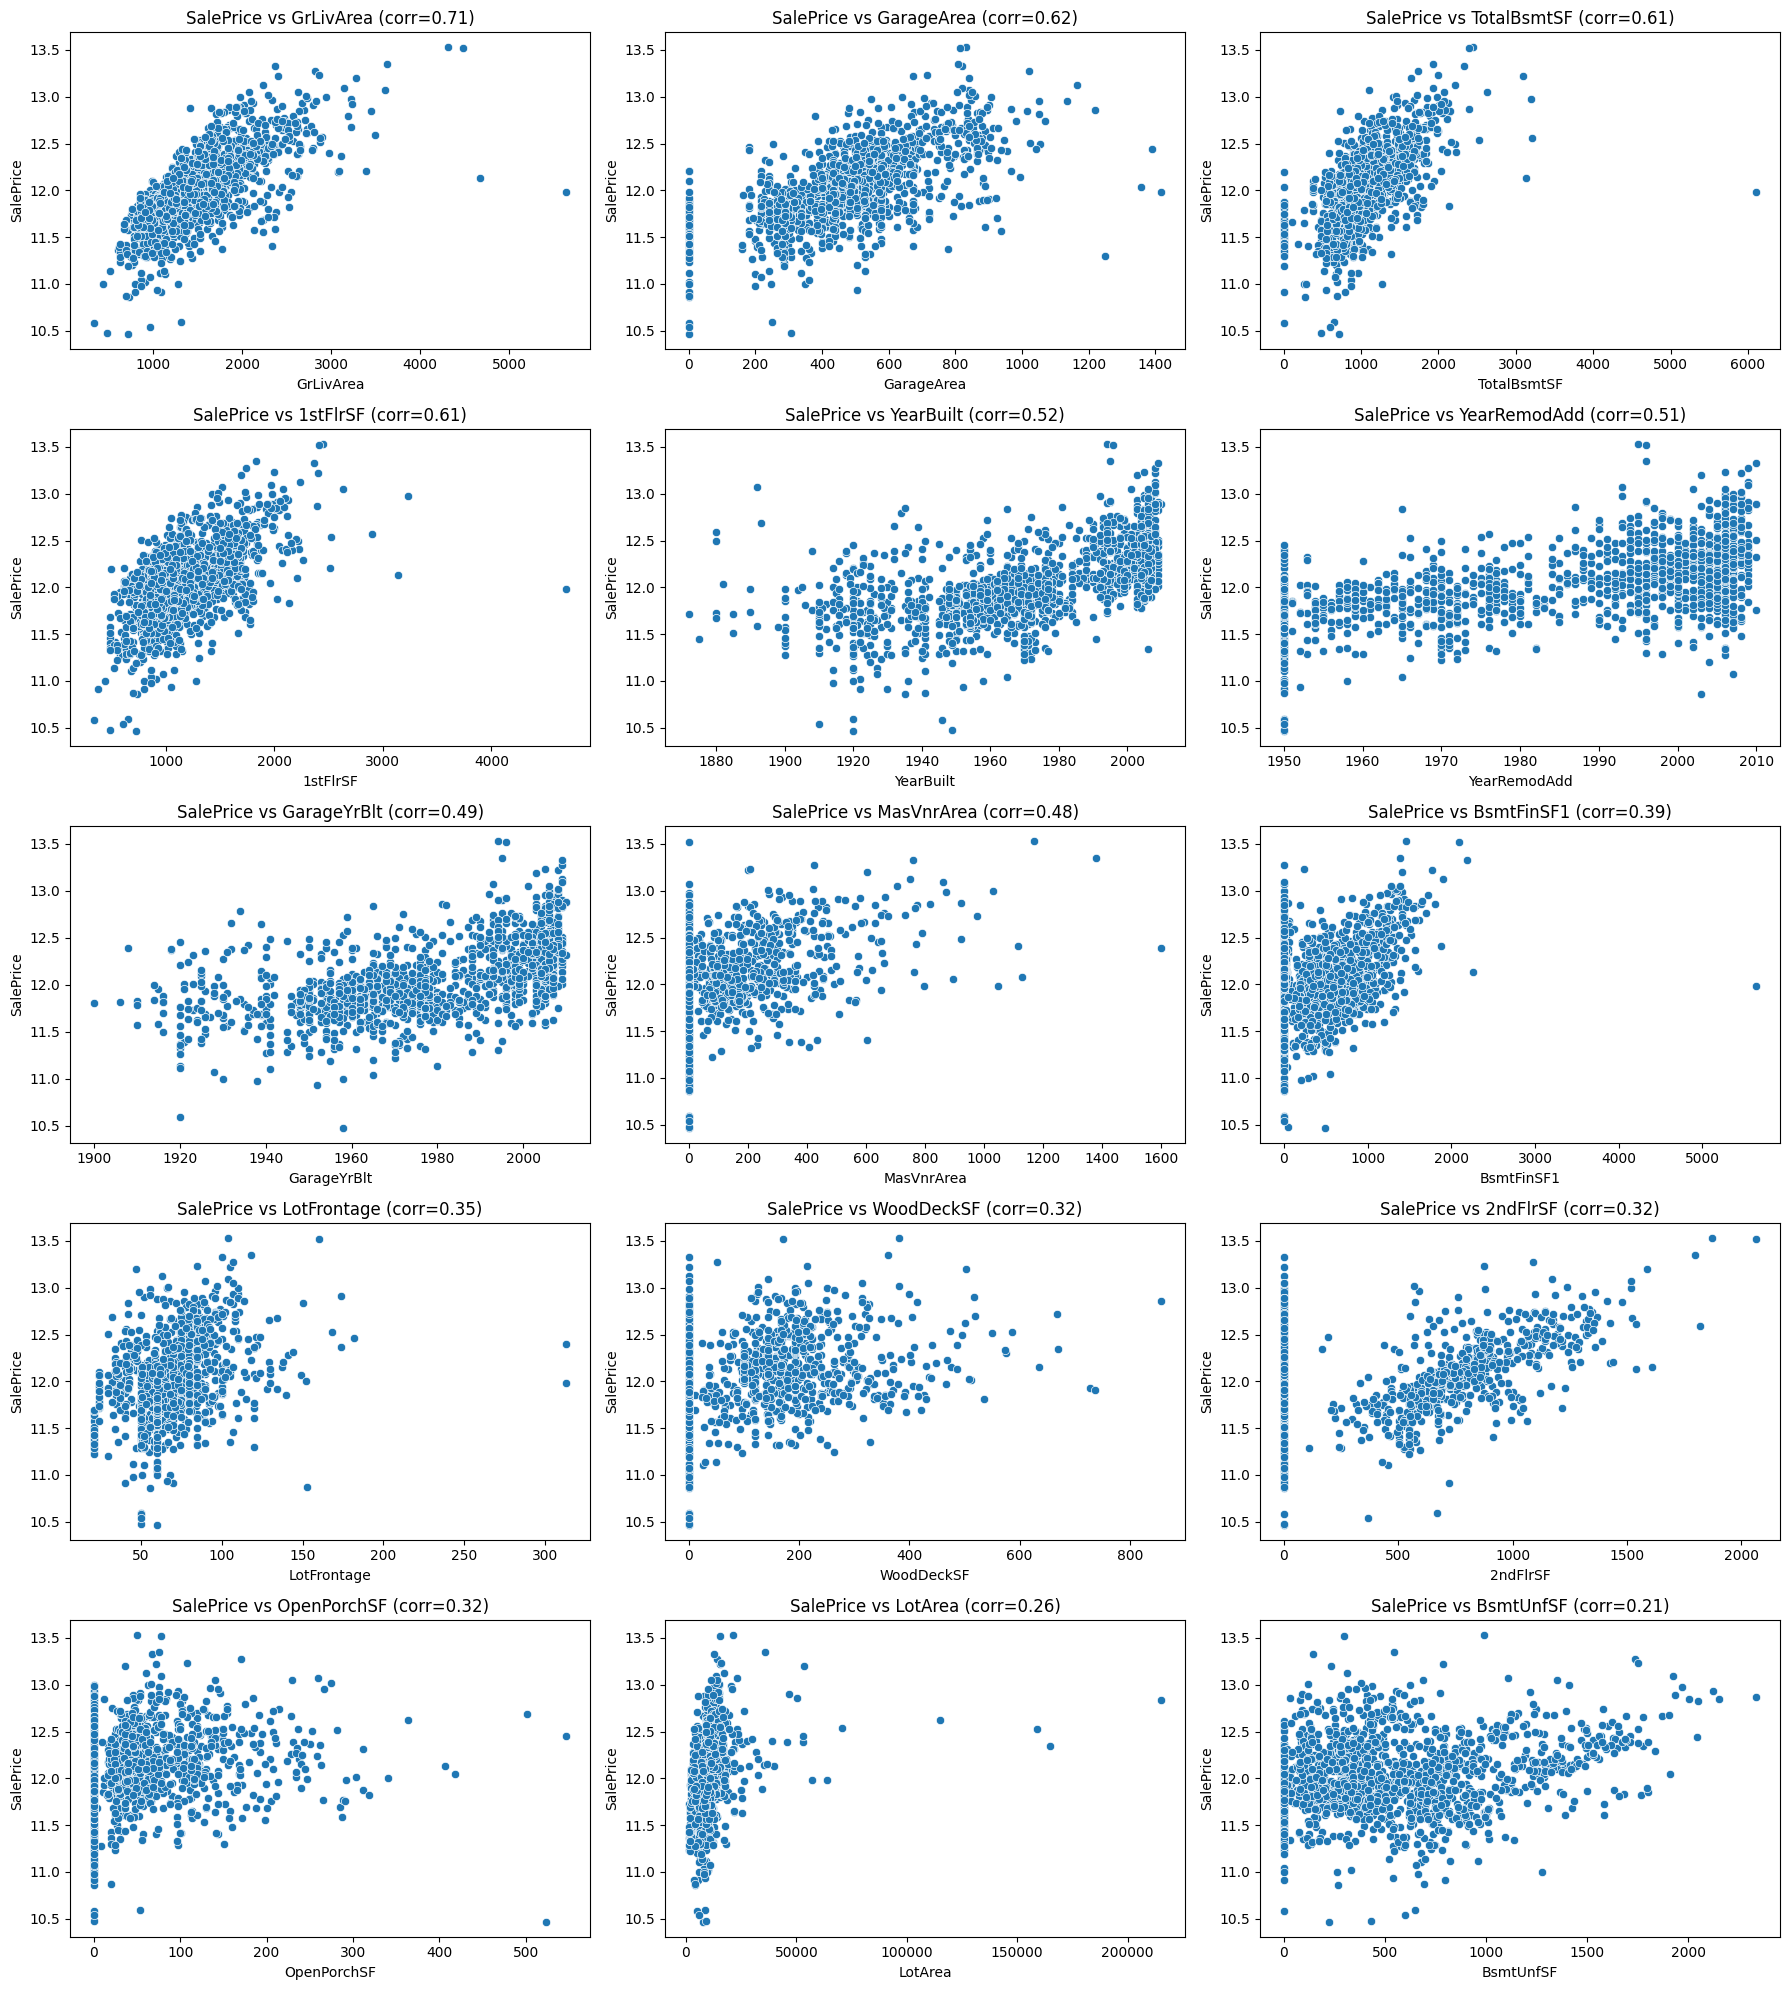

In [28]:
# Scatter plots for numerical features with high correlation - 3 plots per row
import math

num_features = len(continuous_numerical_features)
cols = 3

if num_features == 0:
    print("No contuinuous numerical features")
else:
    rows = math.ceil(num_features / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(continuous_numerical_features):
        sns.scatterplot(
            x=X_train_val[feature],
            y=y_train_val_log,
            ax=axes[i]
        )
        axes[i].set_title(f'SalePrice vs {feature} (corr={corr[feature]:.2f})')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('SalePrice')

    # Remove unused axes when number of features is not a multiple of 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [29]:
# We have to separate binary features from continuous numerical features, 
# because they need to be treated differently in the preprocessing step. 
# We have to create binary features from continuous numerical features with a threshold, to capture the presence or absence of a feature. For example, for the feature "GarageCars", which represents the number of cars that can fit in the garage, we can create a binary feature "HasGarage" that indicates whether the house has a garage or not (1 if GarageCars > 0, 0 otherwise). This way, we can capture the effect of having a garage on the house price, regardless of the number of cars it can fit.

# Binary feature for GarageArea
X_train_val["HasGarage"] = (X_train_val["GarageArea"] > 0).astype(int)
X_test["HasGarage"] = (X_test["GarageArea"] > 0).astype(int)
# Binary feature for TotalBsmtSF
X_train_val["HasBasement"] = (X_train_val["TotalBsmtSF"] > 0).astype(int)
X_test["HasBasement"] = (X_test["TotalBsmtSF"] > 0).astype(int)
# Binary feature for YearRemodAdd
X_train_val["Remodeled"] = (X_train_val["YearRemodAdd"] != X_train_val["YearBuilt"]).astype(int)
X_test["Remodeled"] = (X_test["YearRemodAdd"] != X_test["YearBuilt"]).astype(int)
# Binary feature for MasVnrArea
X_train_val["HasMasVnr"] = (X_train_val["MasVnrArea"] > 0).astype(int)
X_test["HasMasVnr"] = (X_test["MasVnrArea"] > 0).astype(int)
# Binary feature for BsmtFinSF1
X_train_val["HasFinSF1"] = (X_train_val["BsmtFinSF1"] > 0).astype(int)
X_test["HasFinSF1"] = (X_test["BsmtFinSF1"] > 0).astype(int)
# Binary feature for LotFrontage
X_train_val["HasLotFrontage"] = (X_train_val["LotFrontage"] > 0).astype(int)
X_test["HasLotFrontage"] = (X_test["LotFrontage"] > 0).astype(int)
# Binary feature for WoodDeckSF
X_train_val["HasWoodDeck"] = (X_train_val["WoodDeckSF"] > 0).astype(int)
X_test["HasWoodDeck"] = (X_test["WoodDeckSF"] > 0).astype(int)
# Binary feature for 2ndFlrSF
X_train_val["Has2ndFlr"] = (X_train_val["2ndFlrSF"] > 0).astype(int)
X_test["Has2ndFlr"] = (X_test["2ndFlrSF"] > 0).astype(int)
# Binary feature for OpenPorchSF
X_train_val["HasOpenPorch"] = (X_train_val["OpenPorchSF"] > 0).astype(int)
X_test["HasOpenPorch"] = (X_test["OpenPorchSF"] > 0).astype(int)
# Binary feature for LotArea
X_train_val["HasLotArea"] = (X_train_val["LotArea"] > 0).astype(int)
X_test["HasLotArea"] = (X_test["LotArea"] > 0).astype(int)
#Binary feature for BsmtUnfSF
X_train_val["HasBsmtUnf"] = (X_train_val["BsmtUnfSF"] > 0).astype(int)
X_test["HasBsmtUnf"] = (X_test["BsmtUnfSF"] > 0).astype(int)


In [30]:
# update of the list of numerical features
numerical_features = X_train_val.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features

['LotFrontage',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'ExterQual num',
 'ExterCond num',
 'BsmtQual num',
 'BsmtCond num',
 'HeatingQC num',
 'KitchenQual num',
 'FireplaceQu num',
 'GarageQual num',
 'GarageCond num',
 'PoolQC num',
 'BsmtExposure num',
 'BsmtFinType1 num',
 'BsmtFinType2 num',
 'Functional num',
 'GarageFinish num',
 'PavedDrive num',
 'LandSlope num',
 'OverallQual num',
 'OverallCond num',
 'HasGarage',
 'HasBasement',
 'Remodeled',
 'HasMasVnr',
 'HasFinSF1',
 'HasLotFrontage',
 'HasWoodDeck',
 'Has2ndFlr',
 'HasOpenPorch',
 'HasLotArea

In [31]:
# Deletion of outliers for the feature "GrLivArea" (Above ground living area square footage) which has a strong correlation with the target variable and contains some extreme values that can negatively impact the model's performance. 
# By removing these outliers, we can improve the model's ability to learn from the data and make more accurate predictions.

#Supression of outliers
mask = X_train_val["GrLivArea"] < 4000
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["TotalBsmtSF"] < 3000
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["1stFlrSF"] < 3000
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["GarageArea"] < 1200
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["LotArea"] < 100000
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["MasVnrArea"] < 1000
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["WoodDeckSF"] < 1000
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["OpenPorchSF"] < 500
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["LotFrontage"] < 200
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

mask = X_train_val["BsmtFinSF1"] < 3000
X_train_val = X_train_val[mask]
y_train_val = y_train_val[mask]
y_train_val_log = y_train_val_log[mask]

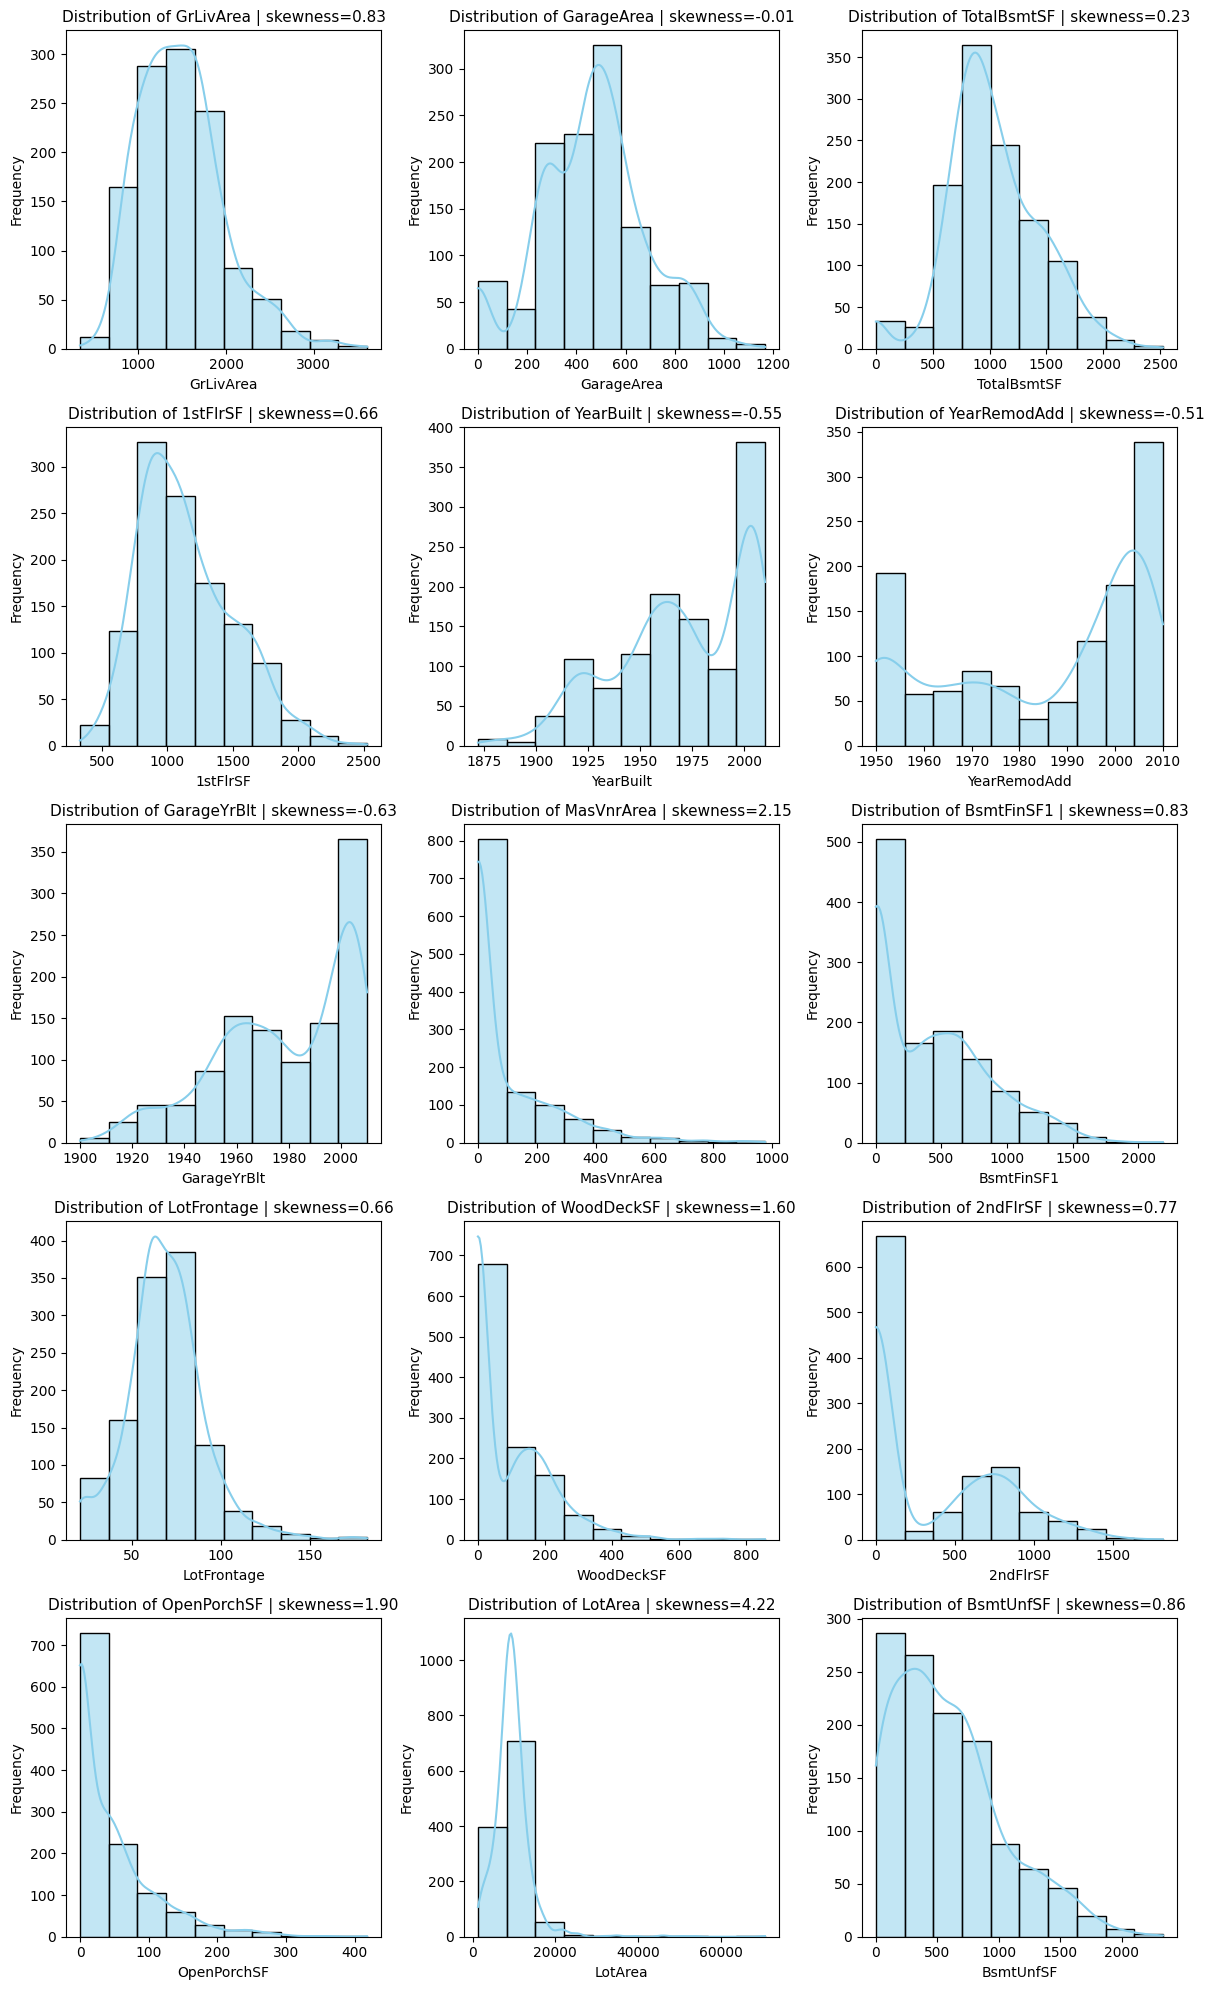

In [32]:
# Histogram for continuous numerical features - 3 plots per row

import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew

# Nombre total de colonnes numériques
num_cols = len(continuous_numerical_features)

# 3 graphiques par ligne
cols = 3
rows = math.ceil(num_cols / cols)

# Créer la grille de sous-graphiques
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

# Boucle sur les colonnes numériques
for i, col in enumerate(continuous_numerical_features):
    series = X_train_val[col].dropna()

    sns.histplot(
        series,
        bins=10,
        kde=True,                  # Ajoute la courbe de densité (lissage)
        color='skyblue',
        edgecolor='black',
        ax=axes[i]
    )

    # Affiche la skewness pour les colonnes numériques
    if pd.api.types.is_numeric_dtype(series):
        sk = skew(series)
        axes[i].set_title(f'Distribution of {col} | skewness={sk:.2f}', fontsize=11)
    else:
        axes[i].set_title(f'Distribution of {col} | skewness=N/A', fontsize=11)

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

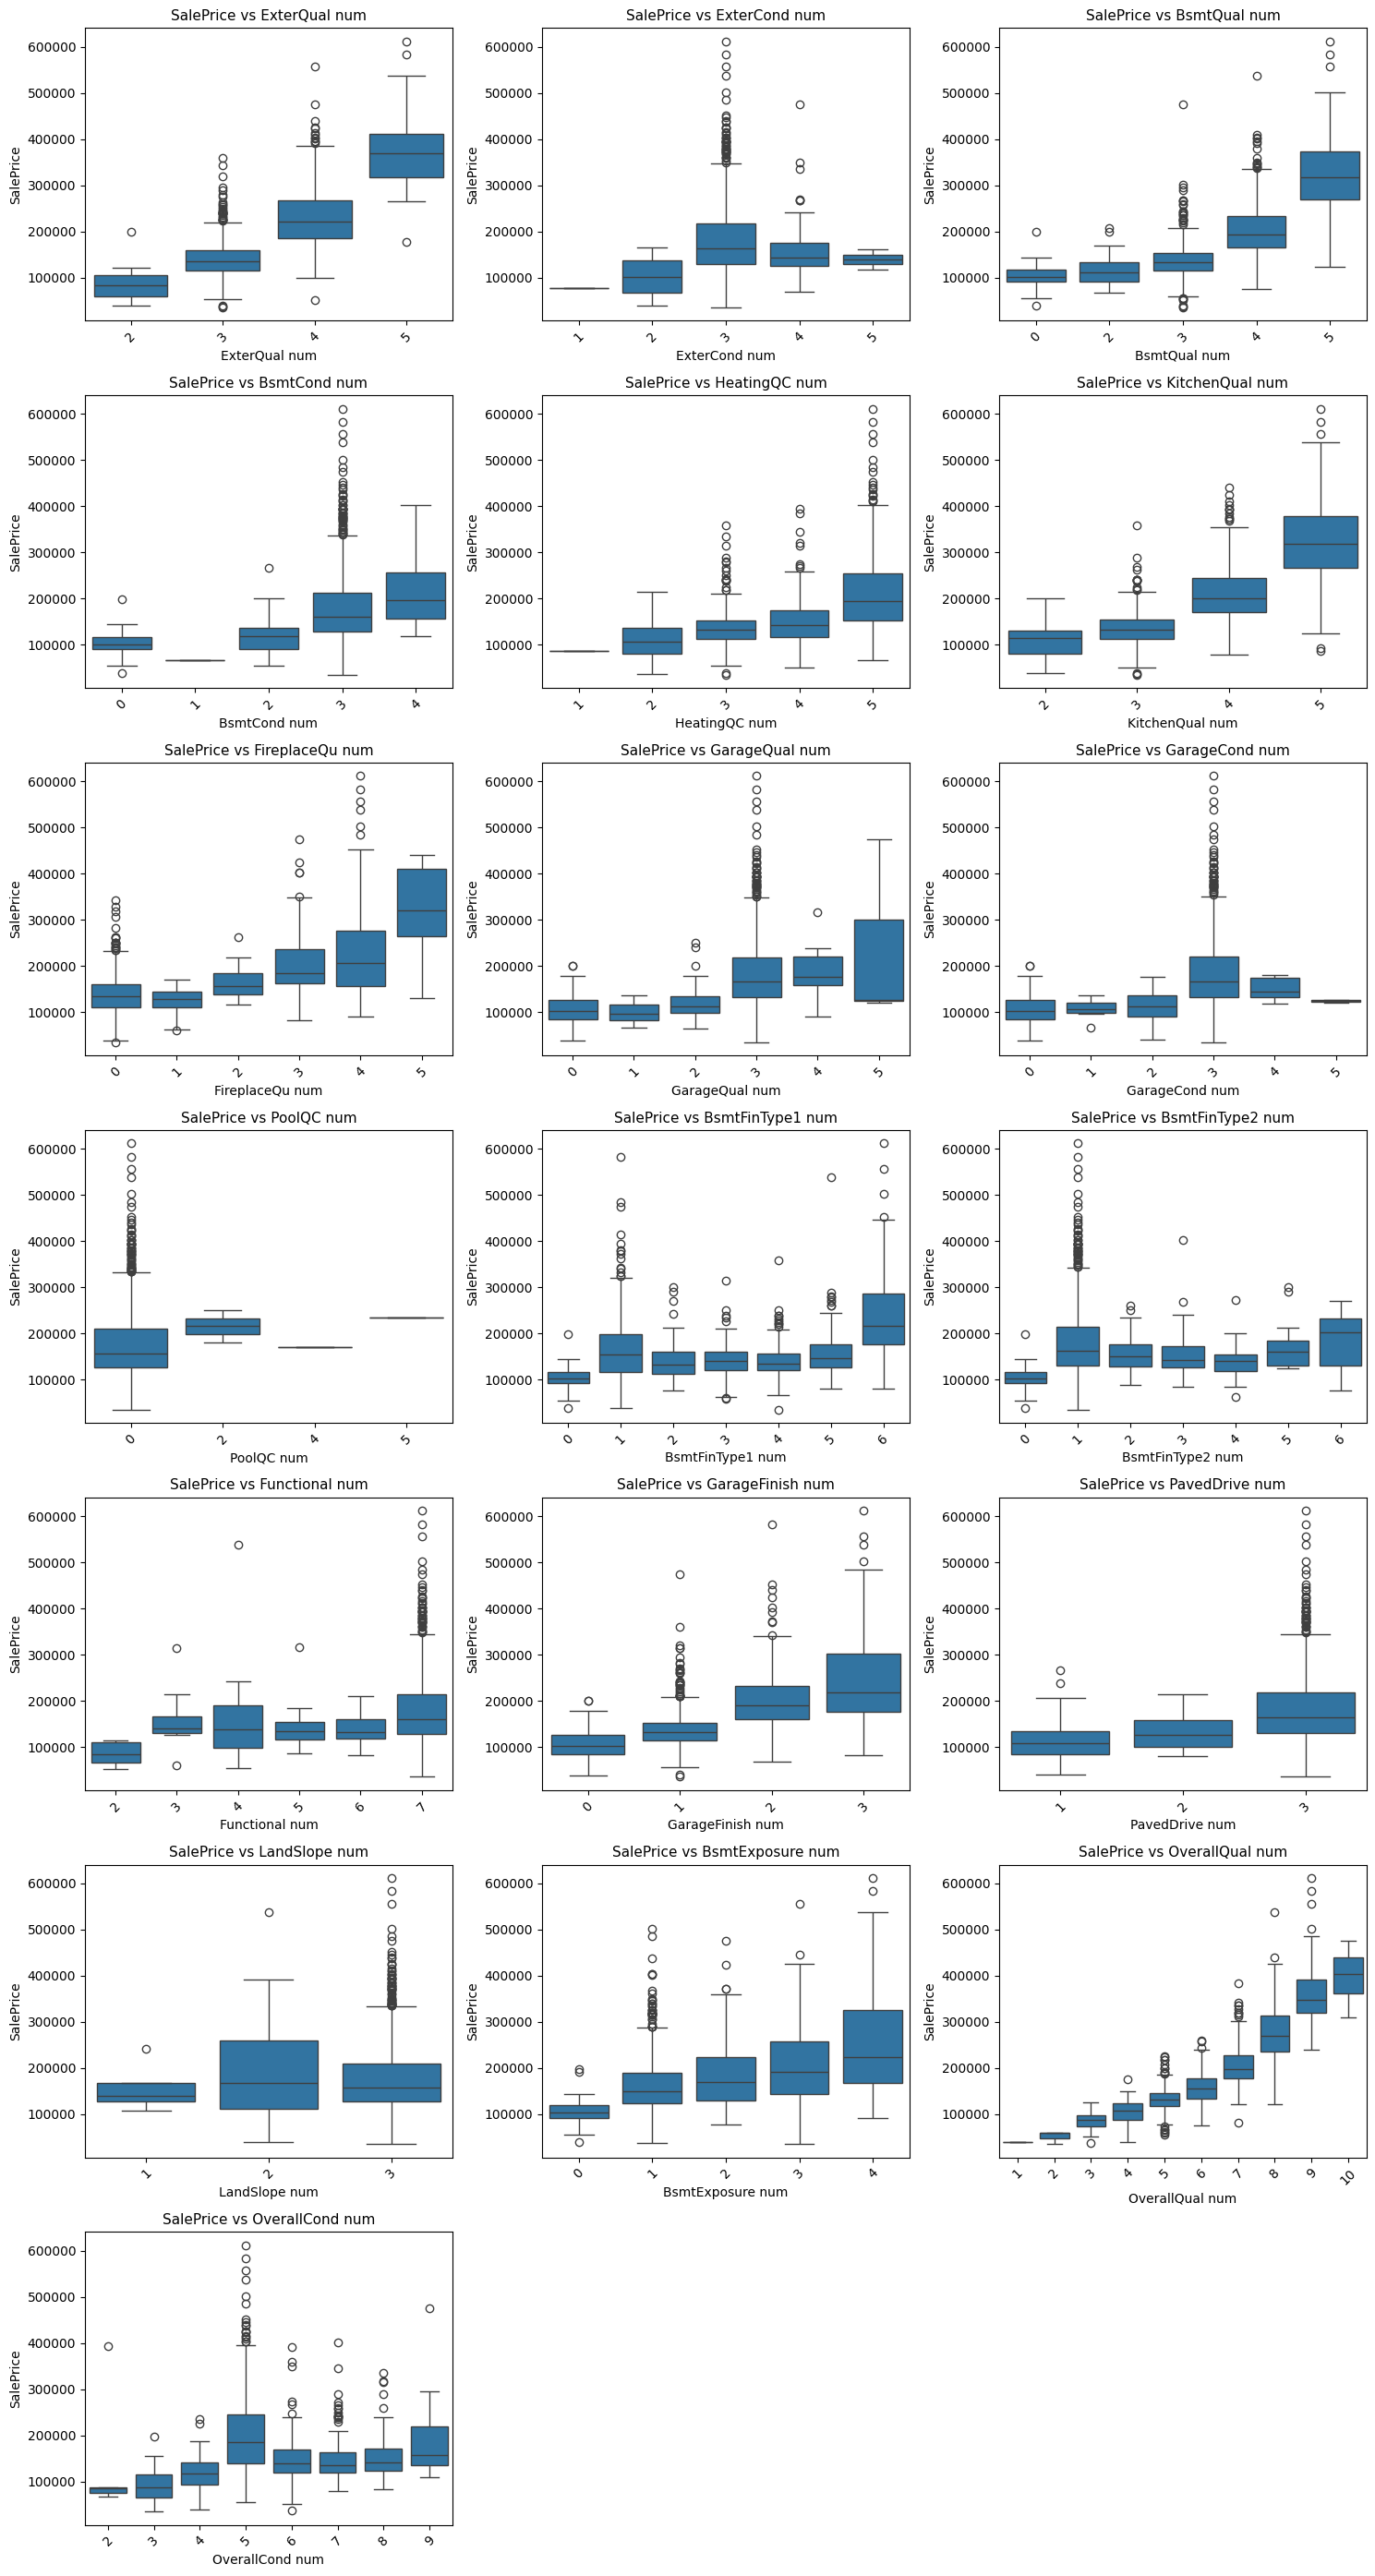

In [33]:
# Box plot for all ordinal features - 3 plots per row
num_cat_features = len(ordinal_features)
cols = 3
rows = math.ceil(num_cat_features / cols)

# Create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = np.array(axes).reshape(-1)

# Loop through ordinal features
for i, feature in enumerate(ordinal_features):
    if feature not in X_train_val.columns:
        continue

    plot_df = (
        X_train_val[[feature]]
        .join(y_train_val.rename("SalePrice"), how="inner")
        .dropna(subset=[feature, "SalePrice"])
    )

    if plot_df.empty:
        continue

    sns.boxplot(data=plot_df, x=feature, y="SalePrice", ax=axes[i])
    axes[i].set_title(f"SalePrice vs {feature}", fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("SalePrice")
    axes[i].tick_params(axis="x", rotation=45)

# Remove unused axes
last_i = i if len(ordinal_features) > 0 else -1
for j in range(last_i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [34]:
#diplay KitchenAbvGr type
print(train_val.KitchenAbvGr.dtype)

int64


In [35]:
#Display the percentage for each values for the feature "KitchenAbvGr" to check if it is a binary feature or not
print(train_val.KitchenAbvGr.value_counts(normalize=True) * 100)

#display correlation between KitchenAbvGr and the target variable
corr_kitchenabvgr = X_train_val["KitchenAbvGr"].corr(y_train_val)
print(f"Correlation between KitchenAbvGr and SalePrice: {corr_kitchenabvgr:.2f}")

KitchenAbvGr
1    95.342466
2     4.452055
3     0.136986
0     0.068493
Name: proportion, dtype: float64
Correlation between KitchenAbvGr and SalePrice: -0.15


In [36]:
# Transformation of the feature "KitchenAbvGr" into several binary features "HasKitchenAbvGr" that indicates whether
# the house has more than one kitchen above ground or zero above ground
X_train_val["HasKitchenAbvGr"] = (X_train_val["KitchenAbvGr"] > 1).astype(int)
X_test["HasKitchenAbvGr"] = (X_test["KitchenAbvGr"] > 1).astype(int)
X_train_val["HasNoKitchenAbvGr"] = (X_train_val["KitchenAbvGr"] == 0).astype(int)
X_test["HasNoKitchenAbvGr"] = (X_test["KitchenAbvGr"] == 0).astype(int)
#deletion of the original feature "KitchenAbvGr" after transformation
X_train_val.drop(columns=["KitchenAbvGr"], inplace=True)
X_test.drop(columns=["KitchenAbvGr"], inplace=True)


In [37]:
# Numerical feature list update
numerical_features = X_train_val.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("Updated numerical features:", numerical_features)

Updated numerical features: ['LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'ExterQual num', 'ExterCond num', 'BsmtQual num', 'BsmtCond num', 'HeatingQC num', 'KitchenQual num', 'FireplaceQu num', 'GarageQual num', 'GarageCond num', 'PoolQC num', 'BsmtExposure num', 'BsmtFinType1 num', 'BsmtFinType2 num', 'Functional num', 'GarageFinish num', 'PavedDrive num', 'LandSlope num', 'OverallQual num', 'OverallCond num', 'HasGarage', 'HasBasement', 'Remodeled', 'HasMasVnr', 'HasFinSF1', 'HasLotFrontage', 'HasWoodDeck', 'Has2ndFlr', 'HasOpenPorch', 'HasLotArea', 'HasBsmtUnf', 'HasKitchenAbvGr', 'HasNoKitchen

In [38]:
# Categorical feature list update
categorical_features = X_train_val.select_dtypes(include=["object", "string"]).columns.tolist()
categorical_features

['MSZoning',
 'LotShape',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'Foundation',
 'Heating',
 'CentralAir',
 'Electrical',
 'GarageType',
 'SaleType',
 'SaleCondition',
 'MSSubClass cat']

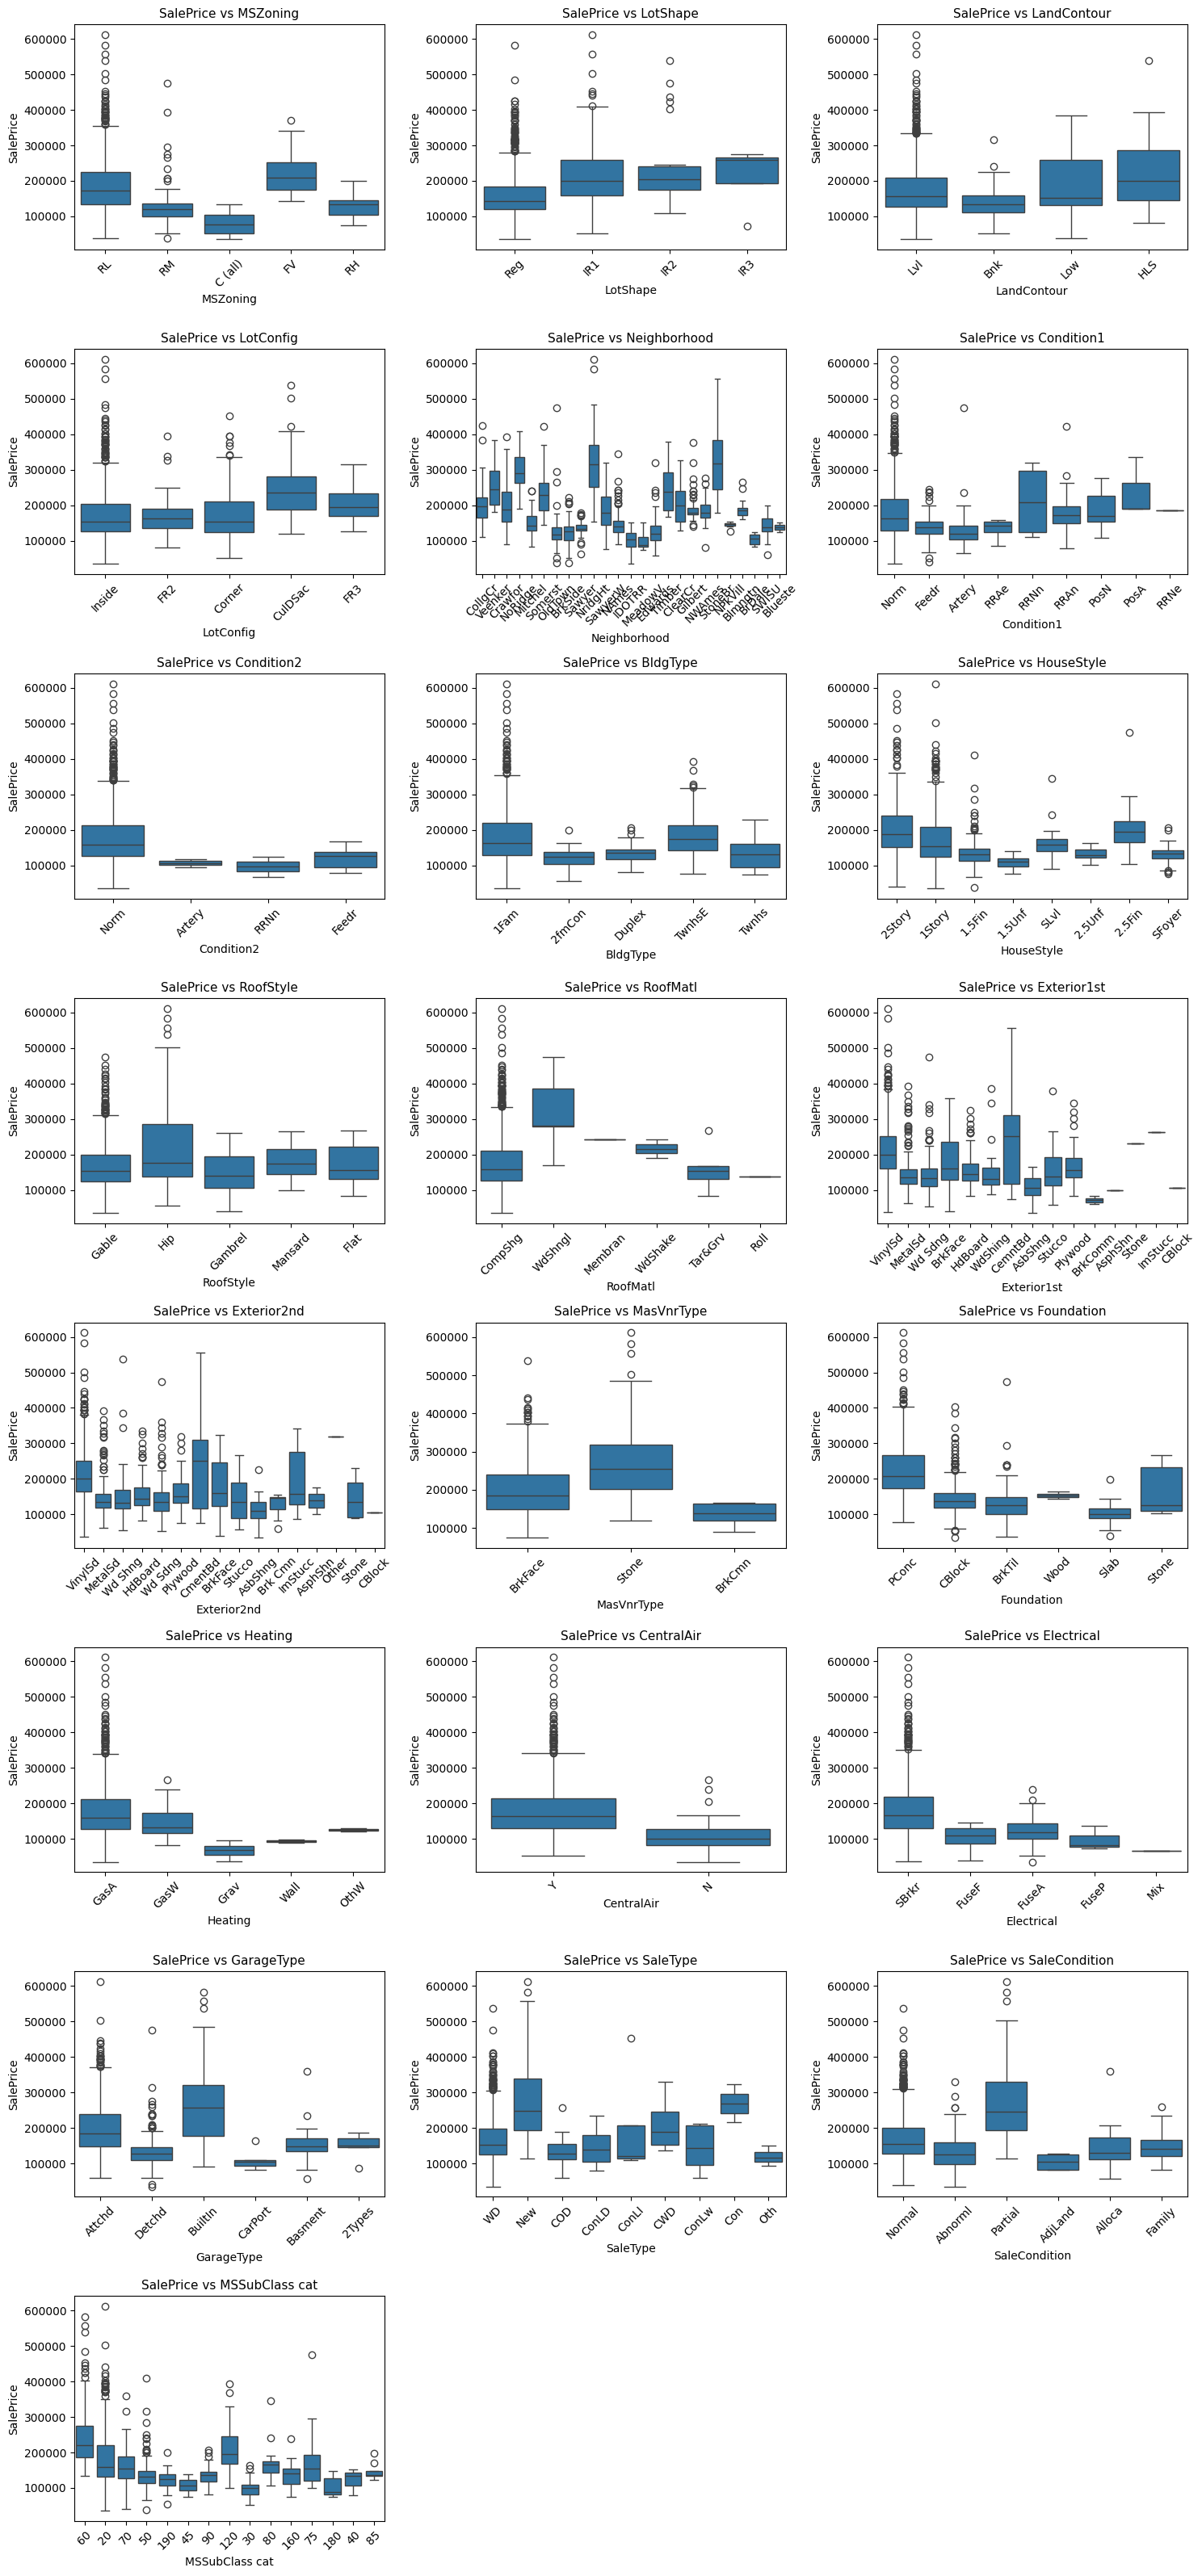

In [39]:
# Box plot for all categorical features except ordinal features - 3 plots per row
num_cat_features = len(categorical_features) 
cols = 3
rows = math.ceil(num_cat_features / cols)

# Create subplot grid
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

# Loop through categorical features
for i, feature in enumerate(categorical_features):
    sns.boxplot(x=X_train_val[feature], y=y_train_val, ax=axes[i])
    axes[i].set_title(f'SalePrice vs {feature}', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('SalePrice')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [40]:
# Transformation of CentralAir feature into a binary feature "HasCentralAir" 
# that indicates whether the house has central air conditioning or not
X_train_val["HasCentralAir"] = (X_train_val["CentralAir"] == "Y").astype(int)
X_test["HasCentralAir"] = (X_test["CentralAir"] == "Y").astype(int)
# Deletion of the original feature "CentralAir" after transformation
X_train_val.drop(columns=["CentralAir"], inplace=True)
X_test.drop(columns=["CentralAir"], inplace=True)
#update of the list of categorical features after transformation
categorical_features = X_train_val.select_dtypes(include=["object", "string"]).columns.tolist()
#update of the list of numerical features after transformation
numerical_features = X_train_val.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [41]:
# Transormation of LotShape feature into ordonal feature with mapping based on the order of the categories in data description
lotshape_mapping = {"Reg": 4, "IR1": 3, "IR2": 2, "IR3": 1}
X_train_val["LotShape num"] = X_train_val["LotShape"].map(lotshape_mapping)
X_test["LotShape num"] = X_test["LotShape"].map(lotshape_mapping)
# Deletion of the original feature "LotShape" after transformation
X_train_val.drop(columns=["LotShape"], inplace=True)
X_test.drop(columns=["LotShape"], inplace=True)
#update of the list of categorical features after transformation
categorical_features = X_train_val.select_dtypes(include=["object", "string"]).columns.tolist()
#update of the list of numerical features after transformation
numerical_features = X_train_val.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [42]:
X_train_val[numerical_features+categorical_features].head(5)

,LotFrontage,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,...,Exterior1st,Exterior2nd,MasVnrType,Foundation,Heating,Electrical,GarageType,SaleType,SaleCondition,MSSubClass cat
Id,,,,,,,,,,,,,,,,,,,,,
1,65.0,8450,2003,2003,196.0,706,0,150,856,856,...,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,WD,Normal,60
2,80.0,9600,1976,1976,0.0,978,0,284,1262,1262,...,MetalSd,MetalSd,NaN,CBlock,GasA,SBrkr,Attchd,WD,Normal,20
3,68.0,11250,2001,2002,162.0,486,0,434,920,920,...,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,WD,Normal,60
4,60.0,9550,1915,1970,0.0,216,0,540,756,961,...,Wd Sdng,Wd Shng,NaN,BrkTil,GasA,SBrkr,Detchd,WD,Abnorml,70
5,84.0,14260,2000,2000,350.0,655,0,490,1145,1145,...,VinylSd,VinylSd,BrkFace,PConc,GasA,SBrkr,Attchd,WD,Normal,60


In [43]:
feature_list = X_train_val.columns.to_list()
feature_list

['MSZoning',
 'LotFrontage',
 'LotArea',
 'LandContour',
 'LotConfig',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'YearBuilt',
 'YearRemodAdd',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'MasVnrArea',
 'Foundation',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 'Heating',
 'Electrical',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageType',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SaleType',
 'SaleCondition',
 'MSSubClass cat',
 'ExterQual num',
 'ExterCond num',
 'BsmtQual num',
 'BsmtCond num',
 'HeatingQC num',
 'KitchenQual num',
 'FireplaceQu num',
 'GarageQual num',
 'GarageCond num',
 'PoolQC num',
 'BsmtExposure num',
 'BsmtFinType1 num',
 'Bsmt

In [44]:
# Total living area (basement + floors)
X_train_val["TotalSF"] = X_train_val["TotalBsmtSF"] + X_train_val["1stFlrSF"] + X_train_val["2ndFlrSF"]
X_test["TotalSF"] = X_test["TotalBsmtSF"] + X_test["1stFlrSF"] + X_test["2ndFlrSF"]
# Age of the house
X_train_val["HouseAge"] = X_train_val["YrSold"] - X_train_val["YearBuilt"]
X_test["HouseAge"] = X_test["YrSold"] - X_test["YearBuilt"]
# Total number of bathrooms
X_train_val["TotalBath"] = X_train_val["FullBath"] + (0.5 * X_train_val["HalfBath"])+ X_train_val["BsmtFullBath"] + (0.5 * X_train_val["BsmtHalfBath"])
X_test["TotalBath"] = X_test["FullBath"] + (0.5 * X_test["HalfBath"])+ X_test["BsmtFullBath"] + (0.5 * X_test["BsmtHalfBath"])
# Lot area minus house area
X_train_val["LotAreaMinusSF"] = X_train_val["LotArea"] - X_train_val["1stFlrSF"]
X_test["LotAreaMinusSF"] = X_test["LotArea"] - X_test["1stFlrSF"]
# Overall quality weighted by house age
X_train_val["OverallQualAge"] = X_train_val["OverallQual num"] / (X_train_val["HouseAge"] + 1)
X_test["OverallQualAge"] = X_test["OverallQual num"] / (X_test["HouseAge"] + 1)
# Quality * area
X_train_val["QualSF"] = X_train_val["OverallQual num"] * X_train_val["TotalSF"]
X_test["QualSF"] = X_test["OverallQual num"] * X_test["TotalSF"]
# Total surface with garage
X_train_val["TotalSFWithGarage"] = X_train_val["TotalSF"] + X_train_val["GarageArea"]
X_test["TotalSFWithGarage"] = X_test["TotalSF"] + X_test["GarageArea"]
# Total surface with porch
X_train_val["TotalSFWithPorch"] = X_train_val["TotalSF"] + X_train_val["OpenPorchSF"] + X_train_val["EnclosedPorch"] + X_train_val["3SsnPorch"] + X_train_val["ScreenPorch"]
X_test["TotalSFWithPorch"] = X_test["TotalSF"] + X_test["OpenPorchSF"] + X_test["EnclosedPorch"] + X_test["3SsnPorch"] + X_test["ScreenPorch"]
# Total number of rooms
X_train_val["TotalRoomSF"] = X_train_val["TotRmsAbvGrd"] + X_train_val["FullBath"] + X_train_val["HalfBath"] + X_train_val["BsmtFullBath"] + X_train_val["BsmtHalfBath"]
X_test["TotalRoomSF"] = X_test["TotRmsAbvGrd"] + X_test["FullBath"] + X_test["HalfBath"] + X_test["BsmtFullBath"] + X_test["BsmtHalfBath"]
# Age after remodeling
X_train_val["AgeAfterRemod"] = X_train_val["YrSold"] - X_train_val["YearRemodAdd"]
X_test["AgeAfterRemod"] = X_test["YrSold"] - X_test["YearRemodAdd"]


In [45]:
X_train_val = X_train_val.replace([np.inf, -np.inf], np.nan)

In [46]:
X_test = X_test.replace([np.inf, -np.inf], np.nan)

In [47]:
continuous_numerical_features = [col for col in numerical_top_features if X_train_val[col].nunique() > 20]

In [48]:
from scipy.stats import skew

# Identify numerical features with high skewness (threshold = 1)
skewness = X_train_val[continuous_numerical_features].apply(lambda col: skew(col.dropna()))
skewed_cols = skewness[abs(skewness) > 1].index.tolist()

print(f"Colonnes transformées avec log1p ({len(skewed_cols)}) :")
print(skewed_cols)

# Apply log1p to skewed columns (log1p handles zeros safely)
X_train_val[skewed_cols] = np.log1p(X_train_val[skewed_cols].clip(lower=0))
X_test[skewed_cols] = np.log1p(X_test[skewed_cols].clip(lower=0))


Colonnes transformées avec log1p (4) :
['MasVnrArea', 'WoodDeckSF', 'OpenPorchSF', 'LotArea']


In [49]:
continuous_numerical_features = [col for col in numerical_top_features if X_train_val[col].nunique() > 20]

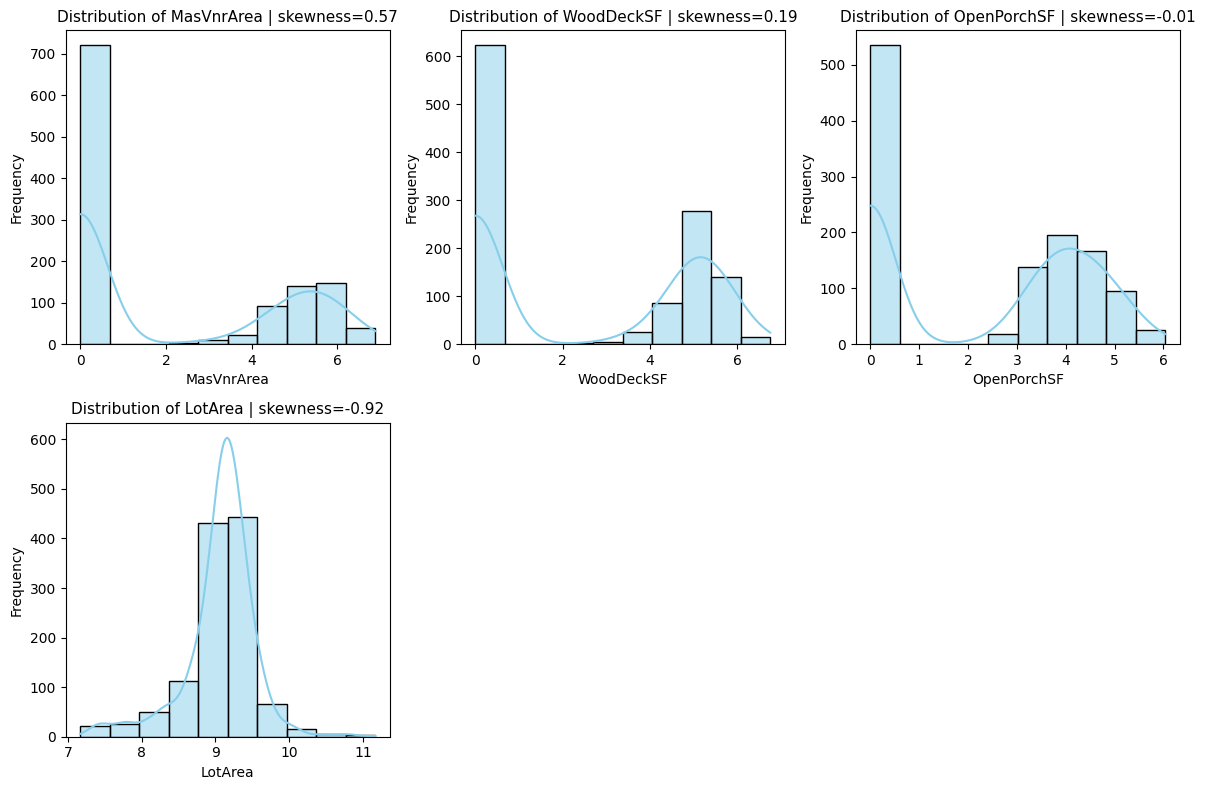

In [50]:
# Histogram for log skewed numerical features - 3 plots per row

import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew

# Nombre total de colonnes numériques
num_cols = len(skewed_cols)

# 3 graphiques par ligne
cols = 3
rows = math.ceil(num_cols / cols)

# Créer la grille de sous-graphiques
fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

# Boucle sur les colonnes numériques
for i, col in enumerate(skewed_cols):
    series = X_train_val[col].dropna()

    sns.histplot(
        series,
        bins=10,
        kde=True,                  # Ajoute la courbe de densité (lissage)
        color='skyblue',
        edgecolor='black',
        ax=axes[i]
    )

    # Affiche la skewness pour les colonnes numériques
    if pd.api.types.is_numeric_dtype(series):
        sk = skew(series)
        axes[i].set_title(f'Distribution of {col} | skewness={sk:.2f}', fontsize=11)
    else:
        axes[i].set_title(f'Distribution of {col} | skewness=N/A', fontsize=11)

    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Supprimer les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

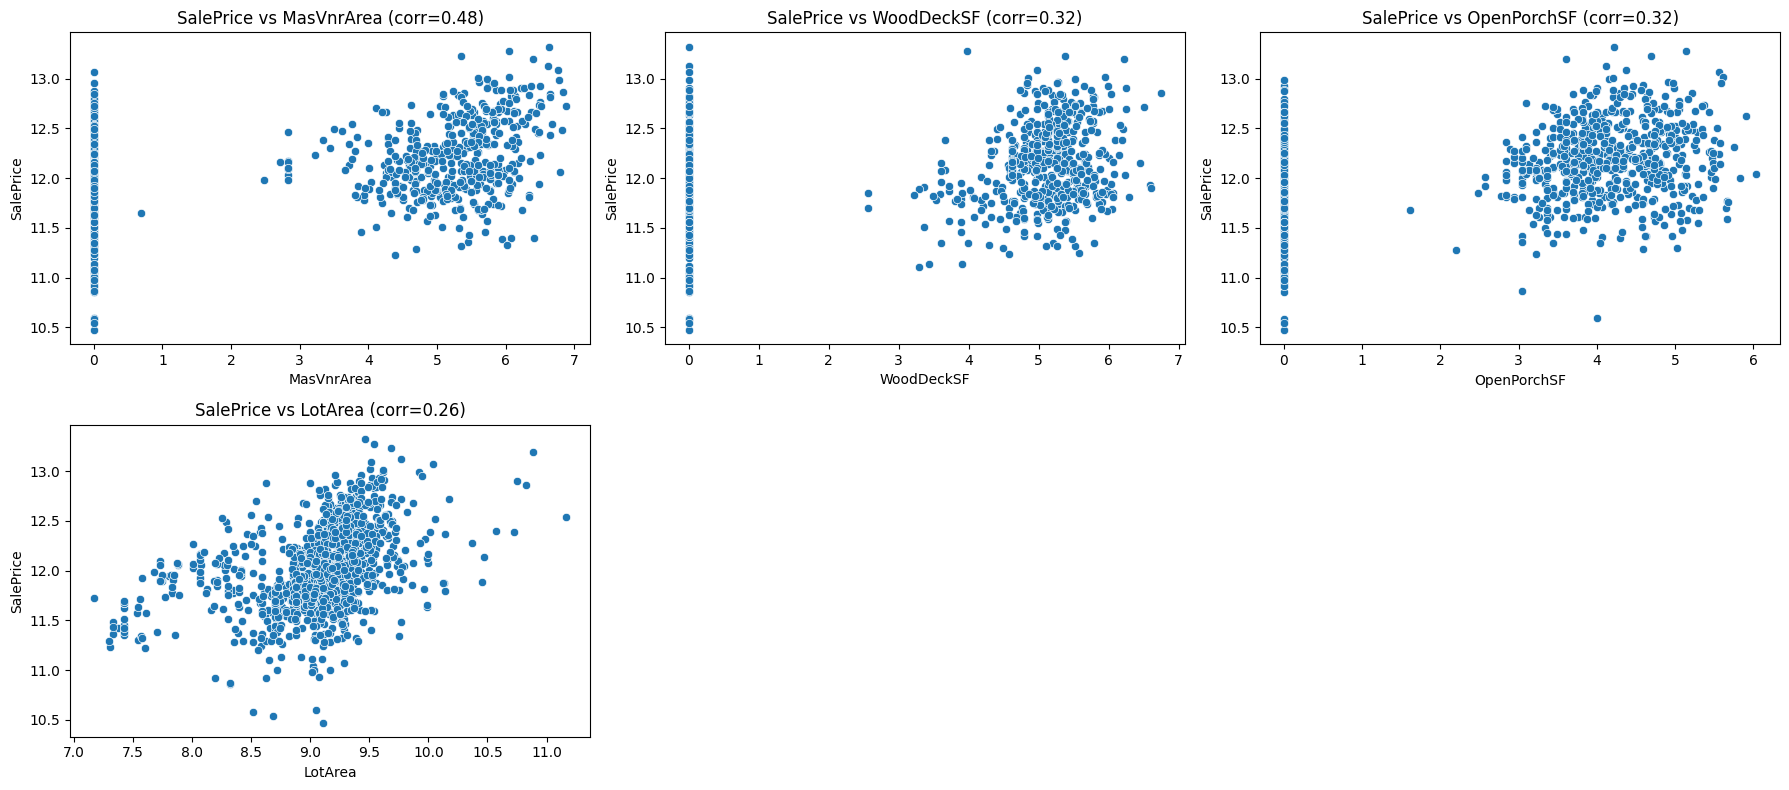

In [51]:
# Scatter plots for log skewed numerical features with high correlation - 3 plots per row
import math
num_skewed_features = len(skewed_cols)
cols = 3

if num_skewed_features == 0:
    print("No feature skewed")
else:
    rows = math.ceil(num_skewed_features / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(skewed_cols):
        sns.scatterplot(
            x=X_train_val[feature],
            y=y_train_val_log,
            ax=axes[i]
        )
        axes[i].set_title(f'SalePrice vs {feature} (corr={corr[feature]:.2f})')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('SalePrice')

    # Remove unused axes when number of features is not a multiple of 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [52]:
# Remove constant features (including columns that are entirely NaN)
constant_cols = [col for col in X_train_val[numerical_features+categorical_features].columns if X_train_val[col].nunique(dropna=False) <= 1]

print(f"Nombre de features constantes supprimées: {len(constant_cols)}")
if constant_cols:
    print(constant_cols)

X_train_val = X_train_val.drop(columns=constant_cols)
X_test = X_test.drop(columns=constant_cols, errors='ignore')

# Update of numerical and categorical features list after removing constant features
numerical_features = X_train_val.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_val.select_dtypes(include=["object", "string"]).columns.tolist()

Nombre de features constantes supprimées: 2
['HasLotFrontage', 'HasLotArea']


In [53]:
#recalculate correlation on numeric features
cols_to_include = list(numerical_features) + ["SalePrice"]
df_corr = (
    X_train_val
    .assign(SalePrice=y_train_val.values)[cols_to_include]
)
corr = df_corr.corr()["SalePrice"].sort_values(ascending=False)
print(corr.head(35))

SalePrice            1.000000
QualSF               0.914825
TotalSFWithGarage    0.852933
TotalSF              0.824642
TotalSFWithPorch     0.820114
OverallQual num      0.809111
ExterQual num        0.723245
GrLivArea            0.708882
KitchenQual num      0.691909
TotalBsmtSF          0.660297
GarageCars           0.660151
GarageArea           0.657583
TotalRoomSF          0.648147
1stFlrSF             0.635767
TotalBath            0.631652
BsmtQual num         0.612584
GarageFinish num     0.587057
YearBuilt            0.565438
FullBath             0.557302
OverallQualAge       0.549597
YearRemodAdd         0.544828
FireplaceQu num      0.537987
TotRmsAbvGrd         0.534588
GarageYrBlt          0.531289
Fireplaces           0.473894
OpenPorchSF          0.471190
HeatingQC num        0.463619
MasVnrArea           0.454182
HasOpenPorch         0.449856
HasMasVnr            0.413004
LotArea              0.407352
BsmtFinSF1           0.402767
BsmtExposure num     0.378632
LotAreaMin

# 3. Data split used for initial baseline model (no cross validation)
Cross validation is done later for more robust evaluation.

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train_log, y_val_log = train_test_split(
    X_train_val, y_train_val_log,  # garde l’alignement index
    test_size=0.2,
    random_state=42
)

# 4. Preprocessing pipeline and train a baseline model (RandomForest)
For initial performance evaluation

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

cat_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy= 'constant', fill_value='None')), 
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
num_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy= 'median')), 
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers = [
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
], remainder='drop' # only keeps the num+cat columns
)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
        ))
])
model.fit(X_train, y_train_log)

y_train_log_pred = model.predict(X_train)
y_val_log_pred   = model.predict(X_val)


from sklearn.metrics import root_mean_squared_error, r2_score
print("Train log RMSE :", root_mean_squared_error(y_train_log, y_train_log_pred))
print("Train log R²:", r2_score(y_train_log, y_train_log_pred))
print("Validation log RMSE :", root_mean_squared_error(y_val_log, y_val_log_pred))
print("Validation log R²:", r2_score(y_val_log, y_val_log_pred))

y_train = np.expm1(y_train_log)          # Inverse of log1p
y_train_pred = np.expm1(y_train_log_pred) 

y_val = np.expm1(y_val_log)          # Inverse of log1p
y_val_pred = np.expm1(y_val_log_pred) 


Train log RMSE : 0.06380424997011193
Train log R²: 0.9755022270348557
Validation log RMSE : 0.1226802358188278
Validation log R²: 0.8997129836262502


# 5. Random Forest evaluation using hyperparameter tuning with cross‑validation
In order to optimize baseline model performance evaluation using RandomizedSearchCV

In [56]:
rf = RandomForestRegressor(random_state=42)

In [57]:
pip_rf = Pipeline([
    ('preproc', preprocessor),
    ('regressor', rf)
])

In [58]:
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [59]:
from scipy.stats import randint
param_rf = {
    'regressor__n_estimators': randint(low=400, high=700), 
    'regressor__max_depth': randint(low=14, high=20),      
    'regressor__min_samples_split': randint(low=4, high=8), 
    'regressor__min_samples_leaf': randint(low=1, high=4),  
    'regressor__max_features': [0.6,0.9]             
}

In [60]:
from sklearn.model_selection import RandomizedSearchCV, KFold
cv = KFold(
    n_splits = 5,
    shuffle = True,
    random_state= 42
)

In [61]:
grid_rf = RandomizedSearchCV(
    estimator = pip_rf,
    param_distributions = param_rf,
    cv=cv,
    scoring= 'neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0,
    n_iter=20
)

In [62]:
grid_rf_fitted = grid_rf.fit(X_train, y_train_log)

In [63]:
grid_rf_fitted.best_params_

{'regressor__max_depth': 14,
 'regressor__max_features': 0.6,
 'regressor__min_samples_leaf': 2,
 'regressor__min_samples_split': 5,
 'regressor__n_estimators': 587}

In [64]:
-grid_rf_fitted.best_score_

np.float64(0.13716554129967132)

In [65]:
best_model = grid_rf_fitted.best_estimator_

In [66]:
# Evaluation of the best model on the validation set
y_val_log_pred_best = best_model.predict(X_val)
print("Validation log RMSE with best model:", root_mean_squared_error(y_val_log, y_val_log_pred_best))
print("Validation log R² with best model:", r2_score(y_val_log, y_val_log_pred_best))

Validation log RMSE with best model: 0.12048498271754346
Validation log R² with best model: 0.9032699647554211


# 6. Comparison of Scikit-learn Models, Catboost and LightGBM with Hyperparameter Tuning using RandomizedSearchCV

In [67]:
from sklearn.model_selection import RandomizedSearchCV, KFold, train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score, mean_squared_error
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import xgboost as xgb
from scipy.stats import loguniform
import lightgbm as lgb
from catboost import CatBoostRegressor


In [68]:
pipelines = {
    "LinearRegression": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())]),
    "RandomForest": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(random_state=42))]),
    "ElasticNet": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', ElasticNet(random_state=42))]),
    "Ridge": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(random_state=42))]),
    "LightGBM": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', lgb.LGBMRegressor(random_state=42, verbose=-1))]),
    "CatBoost": Pipeline(steps=[('preprocessor', preprocessor), ('regressor', CatBoostRegressor(random_state=42, verbose=0))])
}

In [69]:
# Hyperparameter grids for tuning
param_grids = {
    "LinearRegression": {}, # No tuning for simple LinearRegression
    "RandomForest": {
        'regressor__n_estimators': randint(low=400, high=700), 
        'regressor__max_depth': randint(low=14, high=20),      
        'regressor__min_samples_split': randint(low=4, high=8), 
        'regressor__min_samples_leaf': randint(low=1, high=4),  
        'regressor__max_features': [0.6,0.9]  
    },
    "ElasticNet": {
        'regressor__alpha': uniform(0.001, 1.0), # uniform for continuous distribution
        'regressor__l1_ratio': uniform(0.1, 0.9) 
    },
    "Ridge": {
        "regressor__alpha": loguniform(0.1, 10),
        "regressor__fit_intercept": [True],
        "regressor__solver": ["auto", "lsqr", "sparse_cg"],
        "regressor__tol": loguniform(1e-4, 1e-3)
    },
    "LightGBM": {
        'regressor__num_leaves': randint(20, 50),
        'regressor__learning_rate': loguniform(0.01, 0.1),
        'regressor__n_estimators': randint(500, 1000),
        'regressor__max_depth': randint(10, 20),
        'regressor__min_child_samples': randint(20, 50),
        'regressor__subsample': uniform(0.6, 0.4),
        'regressor__colsample_bytree': uniform(0.6, 0.4)
    },
    "CatBoost": {
        'regressor__iterations': randint(500, 1000),
        'regressor__learning_rate': loguniform(0.01, 0.1),
        'regressor__depth': randint(6, 10),
        'regressor__l2_leaf_reg': loguniform(1e-4, 1e-2),
        'regressor__border_count': randint(32, 255)
    }
}

In [70]:

# Cross validation strategy and model evaluation on train set for each model with hyperparameter tuning using RandomizedSearchCV and KFold cross validation.
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_predict

cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)
best_models = {}
cv_scores = {}
best_params_dict = {}
y_train_pred_oof = {}

for name, pipeline in pipelines.items():
    print(f"\n Model : {name}")
    
    if name == "LinearRegression":
        pipeline.fit(X_train, y_train_log)
        best_models[name] = pipeline
        
        # OOF predictions for LinearRegression (CV on X_train only)
        y_train_pred_oof[name] = cross_val_predict(
            best_models[name],
            X_train,
            y_train_log,
            cv=cv_strategy,
            n_jobs=-1,
            method="predict",
        )
        cv_scores[name] = root_mean_squared_error(y_train_log, y_train_pred_oof[name])
        print(f"CV RMSE: {cv_scores[name]:.4f}")
    
    else:
        grid = RandomizedSearchCV(
            pipeline,
            param_distributions=param_grids[name],
            cv=cv_strategy,
            scoring="neg_root_mean_squared_error",
            n_jobs=-1,
            n_iter=20,
            random_state=42,
            verbose=0
        )
        
        grid.fit(X_train, y_train_log)
        
        best_models[name] = grid.best_estimator_
        cv_scores[name] = -grid.best_score_
        best_params_dict[name] = grid.best_params_

        # OOF predictions other models (CV on train only)
        y_train_pred_oof[name] = cross_val_predict(
            best_models[name],
            X_train,
            y_train_log,
            cv=cv_strategy,
            n_jobs=-1,
            method="predict",
        )
        
        print(f"Best CV log RMSE: {-grid.best_score_:.4f}")
        print(f"Best params: {grid.best_params_}")




 Model : LinearRegression
CV RMSE: 0.1410

 Model : RandomForest
Best CV log RMSE: 0.1372
Best params: {'regressor__max_depth': 15, 'regressor__max_features': 0.6, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 4, 'regressor__n_estimators': 556}

 Model : ElasticNet
Best CV log RMSE: 0.1348
Best params: {'regressor__alpha': np.float64(0.021584494295802448), 'regressor__l1_ratio': np.float64(0.9729188669457949)}

 Model : Ridge
Best CV log RMSE: 0.1191
Best params: {'regressor__alpha': np.float64(9.25681899206688), 'regressor__fit_intercept': True, 'regressor__solver': 'auto', 'regressor__tol': np.float64(0.00011128853174905746)}

 Model : LightGBM
Best CV log RMSE: 0.1319
Best params: {'regressor__colsample_bytree': np.float64(0.6185801650879991), 'regressor__learning_rate': np.float64(0.04050837781329675), 'regressor__max_depth': 14, 'regressor__min_child_samples': 28, 'regressor__n_estimators': 666, 'regressor__num_leaves': 37, 'regressor__subsample': np.float64(0

# 7. XGBoost Hyperparameter tuning with Out-of-Fold cross-validation with Early Stopping

In practice, early stopping is typically applied outside of RandomizedSearchCV using a custom cross-validation loop, where full control over the training and validation splits is required.


In [71]:

from scipy.stats import uniform, randint

param_dist = {
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.01, 0.1),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
}

In [72]:
from sklearn.model_selection import ParameterSampler

param_list = list(ParameterSampler(
    param_dist,
    n_iter=20,
    random_state=42
))

In [73]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
best_model_name3 = "XGBoost"
best_score3 = float("inf")
best_n_estimators3 = None
y_train_log_pred3 = None

for params in param_list:
    
    fold_scores = []
    y_train_pred = np.zeros(len(X_train))
    fold_best_iters = []  
    
    for train_idx, val_idx in kf.split(X_train):
        
        X_tr = X_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_tr = y_train_log.iloc[train_idx]
        y_val_oof_fold = y_train_log.iloc[val_idx]

        # preprocessing
        X_tr_trans = preprocessor.fit_transform(X_tr)
        X_val_trans = preprocessor.transform(X_val_fold)

        xgb = XGBRegressor(
            n_estimators=3000,
            objective="reg:squarederror",
            eval_metric="rmse",
            early_stopping_rounds=50,
            random_state=42,
            **params
        )

        xgb.fit(
            X_tr_trans,
            y_tr,
            eval_set=[(X_val_trans, y_val_oof_fold)],
            verbose=False
        )

        y_train_pred[val_idx] = xgb.predict(X_val_trans)

        rmse_log = root_mean_squared_error(y_val_oof_fold, y_train_pred[val_idx])
        fold_scores.append(rmse_log)
        
        # best iteration found by early stopping
        if hasattr(xgb, "best_iteration") and xgb.best_iteration is not None:
            fold_best_iters.append(xgb.best_iteration + 1)
        else:
            fold_best_iters.append(3000)

    mean_rmse_log = np.mean(fold_scores)

    if mean_rmse_log < best_score3:
        best_score3 = mean_rmse_log
        best_n_estimators3 = int((np.mean(fold_best_iters)*1.1))  # Adding a 10% buffer to the average best iteration
        best_params_dict["XGBoost"] = {"params": params, "n_estimators": best_n_estimators3}
        y_train_pred_oof["XGBoost"] = y_train_pred.copy()  # Best model OOF predictions saved for final evaluation

# For XGBoost, we use the best hyperparameters found and the best n_estimators from early stopping
xgb_best = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        random_state=42,
        n_estimators=best_n_estimators3,
        **best_params_dict["XGBoost"]["params"]
    ))
])
# fit the best XGBoost model on the entire training set
xgb_best.fit(X_train, y_train_log)
best_models["XGBoost"] = xgb_best
cv_scores["XGBoost"] = best_score3
best_params_dict["XGBoost"]["n_estimators"] = best_n_estimators3

print("Best CV RMSE XGBoost:", best_score3)
print("Best params:", best_params_dict["XGBoost"])
print("Best n_estimators (average folds):", best_n_estimators3)

Best CV RMSE XGBoost: 0.12408701439127116
Best params: {'params': {'colsample_bytree': np.float64(0.7334834444556088), 'learning_rate': np.float64(0.02428668179219408), 'max_depth': 5, 'subsample': np.float64(0.608233797718321)}, 'n_estimators': 529}
Best n_estimators (average folds): 529


In [74]:
# Best three models scored on the training set with cross validation scores
sorted_scores = sorted(cv_scores.items(), key=lambda x: x[1])
print("\nCV RMSE scores for all models:")
for i, (name, score) in enumerate(sorted_scores, 1):
    print(f"{i}. {name}: {score:.4f}")

best_model_name1, best_score1 = sorted_scores[0]
best_model_name2, best_score2 = sorted_scores[1]
best_model_name3, best_score3 = sorted_scores[2]

print(f"\n 1rst Best model: {best_model_name1}  — CV RMSE : {best_score1:.4f}")
print(f" 2nd Best model: {best_model_name2}  — CV RMSE : {best_score2:.4f}")
print(f" 3rd Best model: {best_model_name3}  — CV RMSE : {best_score3:.4f}")


CV RMSE scores for all models:
1. Ridge: 0.1191
2. CatBoost: 0.1222
3. XGBoost: 0.1241
4. LightGBM: 0.1319
5. ElasticNet: 0.1348
6. RandomForest: 0.1372
7. LinearRegression: 0.1410

 1rst Best model: Ridge  — CV RMSE : 0.1191
 2nd Best model: CatBoost  — CV RMSE : 0.1222
 3rd Best model: XGBoost  — CV RMSE : 0.1241


# 8. Optimization of ensemble weights using OOF predictions
We combine models because they capture different patterns in the data.

In [75]:
from sklearn.metrics import root_mean_squared_error
import numpy as np

# Learn blending weights on OOF predictions from X_train only
top3_names = [best_model_name1, best_model_name2, best_model_name3]

# Weight grid
grid = np.linspace(0, 1, 101)
best_score = float("inf")
best_w = None

for w1 in grid:
    for w2 in grid:
        w3 = 1 - w1 - w2
        if w3 < 0:
            continue

        y_train_log_pred_blend = (
            w1 * y_train_pred_oof[best_model_name1]
            + w2 * y_train_pred_oof[best_model_name2]
            + w3 * y_train_pred_oof[best_model_name3]
        )

        rmse_log = root_mean_squared_error(y_train_log, y_train_log_pred_blend)
        if rmse_log < best_score:
            best_score = rmse_log
            best_w = (w1, w2, w3)

print(f"Best weights (m1, m2, m3): {best_w}")
print(f"Best OOF RMSE (log): {best_score:.5f}")
# Compute blended OOF predictions with the best weights
y_train_log_pred_blend_full = (
    best_w[0] * y_train_pred_oof[best_model_name1]
    + best_w[1] * y_train_pred_oof[best_model_name2]
    + best_w[2] * y_train_pred_oof[best_model_name3]
)
cv_scores["Blended"] = best_score
best_models["Blended"] = "Blended model with OOF weights (not a single sklearn model)"
best_params_dict["Blended"] = {"weights": best_w}


Best weights (m1, m2, m3): (np.float64(0.5700000000000001), np.float64(0.29), np.float64(0.13999999999999996))
Best OOF RMSE (log): 0.11704


# 9. Stacking (Meta model)

In [76]:
X_meta_train_oof = np.column_stack((y_train_pred_oof[best_model_name1], y_train_pred_oof[best_model_name2], y_train_pred_oof[best_model_name3]))

In [77]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
meta_model={}
meta_model["Meta_rf"] = RandomForestRegressor(
    random_state=42
)
y_train_pred_log_meta_rf_oof = cross_val_predict(
    meta_model["Meta_rf"],
    X_meta_train_oof,
    y_train_log,
    cv=5,
    n_jobs=-1,
    method="predict",
)
# Fit the meta-model on the entire training set
meta_model["Meta_rf"].fit(X_meta_train_oof, y_train_log)
cv_scores["Meta_rf"] = root_mean_squared_error(y_train_log, y_train_pred_log_meta_rf_oof)
best_models["Meta_rf"] = "Meta-model (RandomForest) trained on OOF predictions"
best_params_dict["Meta_rf"] = {
    "random_state": 42
}
print(f"Meta-model (RandomForest) OOF RMSE (log): {cv_scores['Meta_rf']:.5f}")



Meta-model (RandomForest) OOF RMSE (log): 0.13087


In [78]:
from sklearn.linear_model import Ridge
meta_model["Meta_ridge"] = Ridge(
    alpha=1.0,
    fit_intercept=True,
    solver="auto",
    tol=1e-4,
    random_state=42
)
y_train_pred_log_meta_ridge_oof = cross_val_predict(
    meta_model["Meta_ridge"],
    X_meta_train_oof,
    y_train_log,
    cv=5,
    n_jobs=-1,
    method="predict",
)
# Fit the meta-model on the entire training set
meta_model["Meta_ridge"].fit(X_meta_train_oof, y_train_log)
cv_scores["Meta_ridge"] = root_mean_squared_error(y_train_log, y_train_pred_log_meta_ridge_oof)
best_models["Meta_ridge"] = "Meta-model (Ridge) trained on OOF predictions"
best_params_dict["Meta_ridge"] = {
    "alpha": loguniform(0.1, 10),
    "fit_intercept": True,
    "solver": "auto",
    "tol": 1e-4
}
print(f"Meta-model (Ridge) OOF RMSE (log): {cv_scores['Meta_ridge']:.5f}")


Meta-model (Ridge) OOF RMSE (log): 0.11780


In [79]:
#Selection of the best model among the unitary, blended and meta models based on oof predictions on the training set with cross validation scores
best_model_name_final = min(cv_scores, key=lambda x: cv_scores[x])
print(f"\nBest model selected for final prediction: {best_model_name_final} ")
print(f"with OOF RMSE (log): {cv_scores[best_model_name_final]:.5f}")


Best model selected for final prediction: Blended 
with OOF RMSE (log): 0.11704


# 10. Predictions and scoring on validation set

In [80]:
# Refit and validation score for the 3 individual best models
y_train_log_pred={}
y_val_log_pred={}
validation_scores_indiv = {}

for name in [best_model_name1, best_model_name2, best_model_name3]:
    print(f"\n{name} - Refit and validation evaluation:")
    best_models[name].fit(X_train, y_train_log)
    y_train_log_pred[name] = best_models[name].predict(X_train)
    y_val_log_pred[name] = best_models[name].predict(X_val)
    rmse_log = root_mean_squared_error(y_val_log, y_val_log_pred[name])
    r2 = r2_score(y_val_log, y_val_log_pred[name])
    validation_scores_indiv[name] = {"RMSE_log": rmse_log, "R2_log": r2}
    print(f"Validation log RMSE: {rmse_log:.4f}")
    print(f"Validation R²: {r2:.4f}")
if best_model_name_final in [best_model_name1, best_model_name2, best_model_name3]:
    validation_score_final = validation_scores_indiv[best_model_name_final]
    print(f"\nSelected model {best_model_name_final} validation log RMSE: {validation_score_final['RMSE_log']:.4f}")
    print(f"Selected model {best_model_name_final} validation R²: {validation_score_final['R2_log']:.4f}")


Ridge - Refit and validation evaluation:
Validation log RMSE: 0.1082
Validation R²: 0.9220

CatBoost - Refit and validation evaluation:
Validation log RMSE: 0.1013
Validation R²: 0.9316

XGBoost - Refit and validation evaluation:
Validation log RMSE: 0.1036
Validation R²: 0.9285


Validation scores can be better than OOF scores because validation uses models refit on the full X_train set, while OOF predictions are generated fold by fold with models trained on about 80% of X_train in each fold. This difference in effective training size can make validation results look more optimistic and does not, by itself, imply data leakage.

In [ ]:
if best_model_name_final == "Blended":
    print(f"Blended validation uses OOF weights (no retuning on validation): {best_w}")

Blended validation uses OOF weights (no retuning on validation): (np.float64(0.5700000000000001), np.float64(0.29), np.float64(0.13999999999999996))


In [82]:
# evaluation on validation set
if best_model_name_final == "Blended":
    # Use OOF-optimized weights to avoid validation leakage
    y_val_log_pred_blend = (
        best_w[0] * y_val_log_pred[best_model_name1]
        + best_w[1] * y_val_log_pred[best_model_name2]
        + best_w[2] * y_val_log_pred[best_model_name3]
    )
    validation_score_final = {
        "RMSE_log": root_mean_squared_error(y_val_log, y_val_log_pred_blend),
        "R2_log": r2_score(y_val_log, y_val_log_pred_blend)
    }
    print(f"\nSelected model {best_model_name_final} validation log RMSE: {validation_score_final['RMSE_log']:.4f}")
    print(f"Selected model {best_model_name_final} validation R²: {validation_score_final['R2_log']:.4f}")
    
elif best_model_name_final.startswith("Meta_"):
    meta_model_final = meta_model[best_model_name_final]
    meta_model_final.fit(X_meta_train_oof, y_train_log)
    X_meta_val = np.column_stack((y_val_log_pred[best_model_name1], y_val_log_pred[best_model_name2], y_val_log_pred[best_model_name3]))
    y_val_log_pred[best_model_name_final] = meta_model_final.predict(X_meta_val)
    validation_score_final = {
        "RMSE_log": root_mean_squared_error(y_val_log, y_val_log_pred[best_model_name_final]),
        "R2_log": r2_score(y_val_log, y_val_log_pred[best_model_name_final])
    }
    print(f"\nSelected model {best_model_name_final} validation log RMSE: {validation_score_final['RMSE_log']:.4f}")


Selected model Blended validation log RMSE: 0.0997
Selected model Blended validation R²: 0.9337


# 11. Refit on all train+val data set

In [83]:
# Refit the best final model on the entire training set (X_train_val) before predicting on the test set
y_train_val_log_pred = {}
for name in [best_model_name1, best_model_name2, best_model_name3]:
    best_models[name].fit(X_train_val, y_train_val_log)
    y_train_val_log_pred[name] = best_models[name].predict(X_train_val)
if best_model_name_final in [best_model_name1, best_model_name2, best_model_name3]:
    final_model = best_models[best_model_name_final]
    print(f"\nSelected model {best_model_name_final} refitted on the entire training set for final prediction.")
elif best_model_name_final == "Blended":
    # Blended model does not require refitting as it is a weighted average of OOF predictions
    print(f"\nSelected blended model {best_model_name_final} for final prediction.")
elif best_model_name_final.startswith("Meta_"):
    X_meta_train_val = np.column_stack((y_train_val_log_pred[best_model_name1], y_train_val_log_pred[best_model_name2], y_train_val_log_pred[best_model_name3]))
    meta_model_final.fit(X_meta_train_val, y_train_val_log)
    final_model = meta_model_final
    print(f"\nSelected meta-model {best_model_name_final} refitted on the entire training set for final prediction.")


Selected blended model Blended for final prediction.


# 12. Final predictions on Test Data and submission

In [84]:
# Final prediction on the test set with the selected best model
y_test_log_pred = {}
for name in [best_model_name1, best_model_name2, best_model_name3]:
    y_test_log_pred[name] = best_models[name].predict(X_test)
if best_model_name_final in [best_model_name1, best_model_name2, best_model_name3]:
        print("Final model prediction on the test set with the selected best model are ready.")
elif best_model_name_final == "Blended":
    # Predictions with the blended model using the same weights found before
    y_test_log_pred[best_model_name_final] = (
        best_w[0] * y_test_log_pred[best_model_name1] +
        best_w[1] * y_test_log_pred[best_model_name2] +
        best_w[2] * y_test_log_pred[best_model_name3]
    )
    print(f"Final blended model {best_model_name_final} predictions on the test set are ready.")
elif best_model_name_final.startswith("Meta_"):
    #predictions with the meta-model using the predictions of the base models as input
    X_meta_test = np.column_stack((y_test_log_pred[best_model_name1], y_test_log_pred[best_model_name2], y_test_log_pred[best_model_name3]))
    y_test_log_pred[best_model_name_final] = meta_model_final.predict(X_meta_test)
    print(f"Final meta-model {best_model_name_final} predictions on the test set are ready.")

Final blended model Blended predictions on the test set are ready.


In [85]:
# Final predictions on the test set with the best model
y_test_pred_final = np.expm1(y_test_log_pred[best_model_name_final])  # Inverse of log1p

In [86]:
# Recording predictions in a CSV file for submission
submission = pd.DataFrame({
    "Id": X_test.index,
    "SalePrice": y_test_pred_final
})
submission.to_csv("submission.csv", index=False)

In [87]:
modele.head(5)

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


In [88]:
submission.head(5)

,Id,SalePrice
0,1461,121606.790104
1,1462,131370.598456
2,1463,182883.483008
3,1464,195218.164615
4,1465,191534.883694


In [89]:
modele.SalePrice.describe()

count      1459.000000
mean     179183.918243
std       16518.303051
min      135751.318893
25%      168703.011202
50%      179208.665698
75%      186789.409363
max      281643.976117
Name: SalePrice, dtype: float64

In [90]:
submission.SalePrice.describe()

count      1459.000000
mean     178255.118819
std       78554.756925
min       51168.796048
25%      126036.947339
50%      155699.880973
75%      208229.657214
max      824504.564513
Name: SalePrice, dtype: float64